<a href="https://colab.research.google.com/github/DanielRojas1920/IAPIA-DanielRojas/blob/Modeltrain/JupyterNotebooks/XRay_Model_PreProcessing_DenseNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chest X-Ray DenseNet**

This notebook is an example demonstrating how to load and explore the Chest X-ray dataset used for training a Deep Learning model. The dataset comprises 112,120 frontal-view X-ray images from 30,805 unique patients. Each image may have multi-label annotations for the following fourteen thoracic pathologies:

- Atelectasis
- Consolidation
- Infiltration
- Pneumothorax
- Edema
- Emphysema
- Fibrosis
- Effusion
- Pneumonia
- Pleural Thickening
- Cardiomegaly
- Nodule
- Mass
- Hernia

The main porpuse of this notebook is train a Machine learning model using DenseNet for backbone, and realize some fine tunning to achive a correct multi-label classification

# Clean environment
This cell remove the default directory created by Google Collab

In [1]:
!rm -rf sample_data

# Installation of the requiered Libraries

If you're using Google Colab, just run the next cell. If you're using a local notebook (e.g., inside of VSC), change the cell language mode to Batch or similar.

In [2]:
!pip install huggingface_hub pandas keras

# Run parameters

## Importing some of the needed libraries

In [3]:
# —— Standard library ——
import os
import re
import ast
import time
from time import sleep
from datetime import timedelta
from pathlib import Path
import zipfile
import csv as csvFile
from glob import glob
from itertools import chain
import shutil
from urllib.request import urlretrieve

# —— Third-party ——
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import json

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split

import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as TF

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    hamming_loss,
    recall_score,
    label_ranking_average_precision_score,
    brier_score_loss,
    f1_score,
    multilabel_confusion_matrix,
    roc_curve,
    auc,
    classification_report,
    precision_score,
    roc_auc_score,
)


# —— Cloud / Hub integrations ——
from huggingface_hub import hf_hub_download
from google.colab import files, drive


#Select the GPU is there is one available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Setting up the global variables

### Dataset
- **DATASET_DOWNLOAD_MODE**: Only One mode Available: HUGGING_FACE
- **backboneLoad**: Specifies if there gonna be a model pre-Charged on on the path: *saved_models/DenseNetTuned*
- **dataExploration**: Specifies if the notebook is gonna show information about the dataSet
- **dataLoad**: Specifies if the notebook will use the pre-processed dataset stored on our [Hugging Face Personal Repository (15 Gb)](https://huggingface.co/datasets/Carlos56g/ChestXRay15GB). Otherwise is gonna use the complete dataset stored on [Hugging Face Complete Repository (40 Gb)](https://huggingface.co/datasets/alkzar90/NIH-Chest-X-ray-dataset) and pre-process the data before training
- **imageDimension**: image dimension used for the model

### Training
- **train**: Specifies if the model is gonna be trained
- **testSize**: Specifies the test size used for training
- **sampleTest**: Specifies if the notebook is gonna use a fraction of the complete dataset
- **sampleSize** = Specifies the fraction of the data used for testing
- **train**: Specifies if the model is gonna be trained
- **epochs**: number of epoch for training
- **batchSize**: Specifies the batchSize
- **learningRate**: learning rate for training
- **ModelSave**: specifies the critiria to select the best model obteined on the training process

### Validation
- **Analyze**: Specifies if the model is gonna be analyzed
- **numPredictions**: Predictions made by the model at the end of the notebook
- **modelName**: Name of the model stored on the files created
- **SummaryWriterTensorBoard**: Specifies if TensorBoard is gonna be shown

In [4]:
HUGGING_FACE = "hugging_face"

##Modify the variables to accomplish your desired result
#Dataset
DATASET_DOWNLOAD_MODE = HUGGING_FACE
backboneLoad = True
dataExploration = True
dataLoad = False
imageDimension = 240

#Training
train = False
testSize = 0.20
sampleTest = False
sampleSize = 0.1
epochs = 3
batchSize = 100 #160
learningRate = 0.001
modelSave = 'MACROF1' # 'AUC','MACROF1', 'PREC'

#Validation
Analyze = True
numPredictions = 20
modelName = "Last Try, Added Drop Out 0.5 3 epochs"
SummaryWriterTensorBoard = False

if dataLoad:
  all_labels = [
      "Hernia",
      "Nodule",
      "Fibrosis",
      "Edema",
      "Cardiomegaly",
      "Effusion",
      "Pneumothorax",
      "Pleural_Thickening",
      "Consolidation",
      "Emphysema",
      "Pneumonia",
      "Mass",
      "Atelectasis",
      "Infiltration"
  ]
else:
  all_labels = [
      "Hernia",
      "Nodule",
      "Fibrosis",
      "No Finding",
      "Edema",
      "Cardiomegaly",
      "Effusion",
      "Pneumothorax",
      "Pleural_Thickening",
      "Consolidation",
      "Emphysema",
      "Pneumonia",
      "Mass",
      "Atelectasis",
      "Infiltration"
  ]

# Local Directories for Model Load
The following cell create the directory where the model is gonna be stored.

If you set the global variable **backboneLoad = True**, the code is gonna wait for the files:
- **model_classification.pt** : Stores the trained wights of the model
- **optimizer_classification.pt** : Stores the optimizer hyperparameters

Upload the files on the folder:

- saved_models\DenseNetTuned

In [5]:
def create_model_dirs():
    model_base_dir.mkdir(parents=True, exist_ok=True)


def setup():
    create_model_dirs()


model_base_dir = Path.cwd() / "saved_models" / "DenseNetTuned"

setup()

while backboneLoad:
    print("Charge your backbone NOW")
    sleep(5)

    optimizer_classification_path = Path.cwd() / "saved_models" / "DenseNetTuned" / "optimizer_classification.pt"
    model_classification_path = Path.cwd() / "saved_models" / "DenseNetTuned" / "model_classification.pt"

    if optimizer_classification_path.exists() and model_classification_path.exists():
        break


Charge your backbone NOW


# Getting the dataset

The following cell obtains the dataset directly from Hugging Face

You can set the variable **dataLoad** to use the Pre-processed dataset or the default one and Pre-process it

The process is:
- Crate a directory **datasets/**
- Download the n-Zip file
- Create a temp file indicating that the file complete the download proccess
- Extract the n-Zip file
- Create a temp file indicating that the file complete the extract proccess
- If **dataLoad** is true charges the data contained on the .csv Files on their corresponding DataFrames

In [6]:
if DATASET_DOWNLOAD_MODE == HUGGING_FACE:

    if(dataLoad):
      REPO_ID = "Carlos56g/ChestXRay15GB"
      FILEPATH = "data/dataframes/final_df.csv"
      NUMBER_OF_IMAGE_ZIPS_TO_DOWNLOAD_FROM_DATASET = 8

    else:
      REPO_ID = "alkzar90/NIH-Chest-X-ray-dataset"
      FILEPATH = "data/Data_Entry_2017_v2020.csv"
      dataset_path = Path(hf_hub_download(repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))
      NUMBER_OF_IMAGE_ZIPS_TO_DOWNLOAD_FROM_DATASET = 12

    datasets_path = Path("datasets/").mkdir(exist_ok=True)


    # Download images
    for i in range(1, NUMBER_OF_IMAGE_ZIPS_TO_DOWNLOAD_FROM_DATASET+1):
        if(dataLoad):
          FILEPATH = f"images_{i:03d}.zip"
        else:
          FILEPATH = f"data/images/images_{i:03d}.zip"

        downloaded_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-downloaded.tmp"

        if downloaded_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            print(f"Downloading {FILEPATH}...")
            zip_path = Path(hf_hub_download(
                repo_id=REPO_ID, filename=FILEPATH, repo_type="dataset", local_dir="datasets/"))

            # Create a temp file that indicates the zip was completely downloaded
            downloaded_tmp_file.mkdir(parents=True, exist_ok=True)
            downloaded_tmp_file.touch()

        extracted_tmp_file = Path("datasets/") / "tmp" / f"zip-{i}-extracted.tmp"
        if extracted_tmp_file.exists():
            print(f"{FILEPATH} already exists. Skipping download.")
        else:
            zipfile.ZipFile(zip_path).extractall("datasets/")

            # Create a temp file that indicates the zip was completely extracted
            extracted_tmp_file.mkdir(parents=True, exist_ok=True)
            extracted_tmp_file.touch()

            os.system(f"rm datasets/{FILEPATH}")

            print("ZIP extracted and removed!")

    print("Dataset downloaded and extracted!")

if dataLoad:
  #Complete dataframe (train,validation,test)
  dataset_path = Path("/content/datasets/data/dataframes/final_df.csv")

  #train_df
  train_df_final=pd.read_csv("/content/datasets/data/dataframes/train_df.csv")
  #validation_df
  validation_df=pd.read_csv("/content/datasets/data/dataframes/validation_df.csv")
  #test_df
  test_df=pd.read_csv("/content/datasets/data/dataframes/test_df.csv")


  #This function is used to convert cells [0 0 0 0 0 1] to [0, 0, 0, 0, 0, 1] in order to be succesfully parsed
  def fix_vector_string(vec):
  # Adds , btw each number
    vec = re.sub(r'(?<=\d)\s+(?=\d)', ', ', vec.strip())
    try:
      return ast.literal_eval(vec)
    except:
      return vec
    return vec

  # Applies this transformation to each dataframe
  for df in [train_df_final, validation_df, test_df]:
      df["disease_vec"] = df["disease_vec"].apply(fix_vector_string)
      df["patient_info"] = df["patient_info"].apply(fix_vector_string)

data/images/images_001.zip already exists. Skipping download.
data/images/images_001.zip already exists. Skipping download.
data/images/images_002.zip already exists. Skipping download.
data/images/images_002.zip already exists. Skipping download.
data/images/images_003.zip already exists. Skipping download.
data/images/images_003.zip already exists. Skipping download.
data/images/images_004.zip already exists. Skipping download.
data/images/images_004.zip already exists. Skipping download.
data/images/images_005.zip already exists. Skipping download.
data/images/images_005.zip already exists. Skipping download.
data/images/images_006.zip already exists. Skipping download.
data/images/images_006.zip already exists. Skipping download.
data/images/images_007.zip already exists. Skipping download.
data/images/images_007.zip already exists. Skipping download.
data/images/images_008.zip already exists. Skipping download.
data/images/images_008.zip already exists. Skipping download.
data/ima

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Data Exploration

Basic information of the Dataset is showed on the next cells.

If you set **dataLoad = True** the following cells are gonna show the information of the preprocess dataset

## Describe()
Descriptive statistics of the numerical columns (by default)

In [7]:
if dataExploration:
  csv_exploration = pd.read_csv(dataset_path)
  csv_exploration.describe()

 ## Head()
 First 5 rows of the DataFrame

In [8]:
if dataExploration:
  csv_exploration.head()

## Deseases Distribution

### Occurrence of each desease (Number)

In [9]:
if dataExploration:
  # Get all labels ['Label1', 'Label3', 'Label1', ...]
  all_labels_exploration = list(chain(*csv_exploration['Finding Labels'].map(lambda x: x.split('|')).tolist()))
  # Get unique {'Label1', 'Label2', 'Label3', ...}
  all_labels_exploration = list(set(all_labels_exploration))

  # Add each label as a column and set 1 if the label was assigned to the image;
  # otherwise, set 0.
  for label in all_labels_exploration:
      csv_exploration[label] = csv_exploration['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

  print(
      '{} Labels\n{}'.format(
        len(all_labels_exploration),
        "\n".join([f"{label}: {int(csv_exploration[label].sum())}" for label in all_labels_exploration]),
      )
  )

15 Labels
Hernia: 227
Emphysema: 2516
Pleural_Thickening: 3385
Cardiomegaly: 2776
Pneumonia: 1431
Fibrosis: 1686
Effusion: 13317
Pneumothorax: 5302
Atelectasis: 11559
Nodule: 6331
Infiltration: 19894
Mass: 5782
Consolidation: 4667
Edema: 2303
No Finding: 60361


### Occurrence of each desease (Graph)

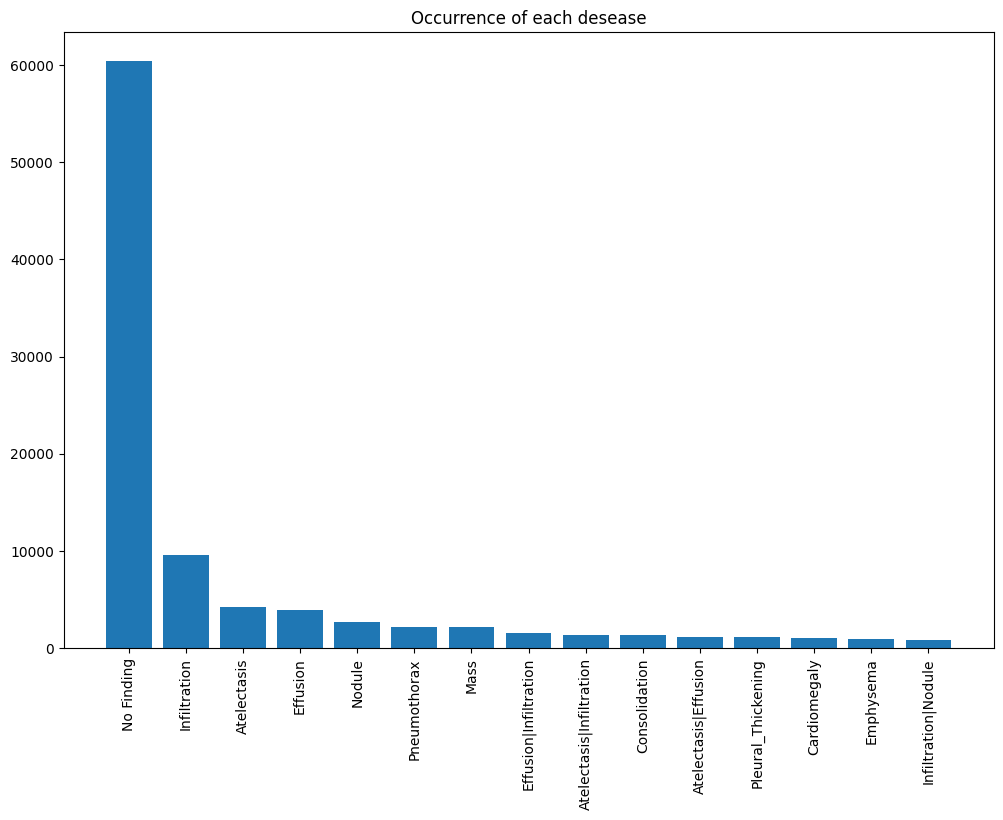

In [10]:
if dataExploration:
  label_counts = csv_exploration['Finding Labels'].value_counts()[:15]

  fig, ax1 = plt.subplots(1,1,figsize = (12, 8))

  ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)

  ax1.set_xticks(np.arange(len(label_counts)) + 0.5)

  _ = ax1.set_xticklabels(label_counts.index, rotation = 90)

  ax1.set_title("Occurrence of each desease")

## Patients Information


### Age

#### Age distribution of the patients (Numeric)

In [11]:
if dataExploration:
  csv_exploration['Patient Age'] = pd.to_numeric(csv_exploration['Patient Age'], errors='coerce')

  unique_patients = csv_exploration.drop_duplicates(subset='Patient ID')

  ages = unique_patients['Patient Age'].dropna()

  ages.value_counts().sort_index()

#### Age distribution of the patients (Graph)

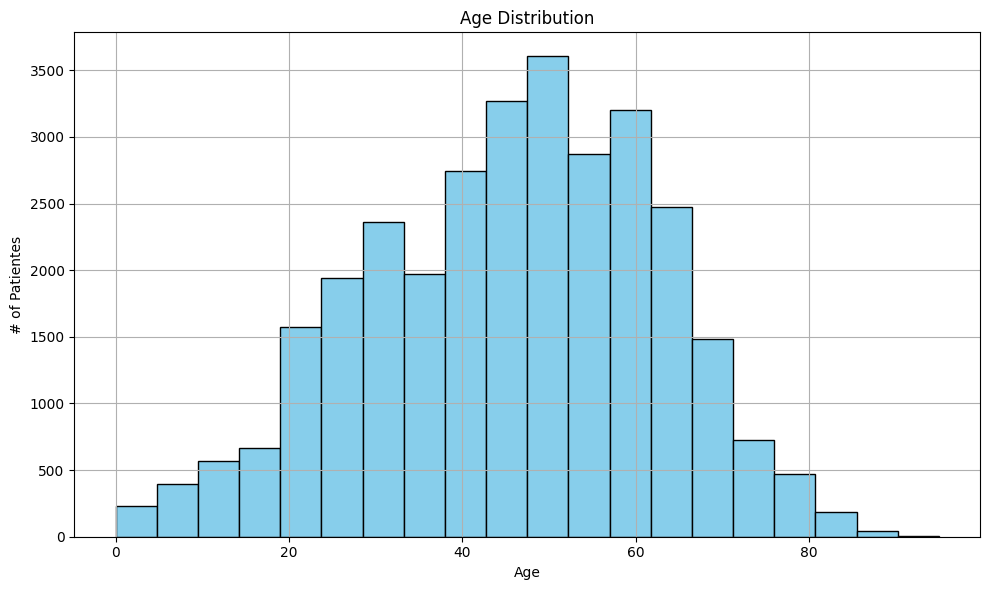

In [12]:
if dataExploration:
  plt.figure(figsize=(10, 6))
  plt.hist(ages, bins=20, edgecolor='black', color='skyblue')

  plt.title('Age Distribution')
  plt.xlabel('Age')
  plt.ylabel('# of Patientes')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

### Gender

#### Gender Distribution (Numeric)

In [13]:
if dataExploration:
  gender_counts = unique_patients['Patient Gender'].value_counts()

  gender_counts

#### Gender Distribution (Graph)

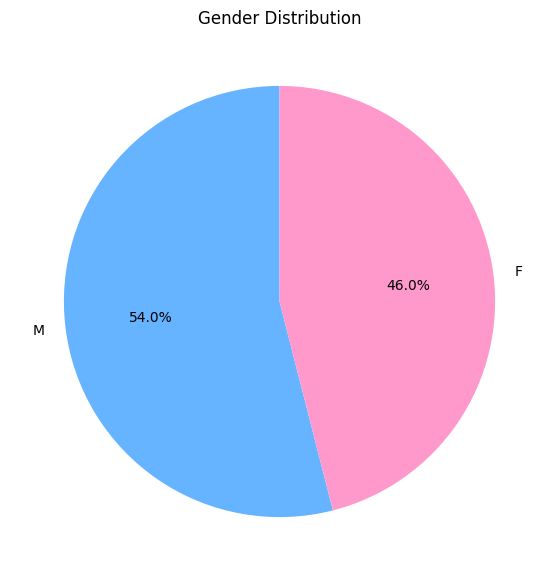

In [14]:
if dataExploration:
  plt.figure(figsize=(7, 7))
  gender_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff', '#ff99cc'], startangle=90, legend=False)


  plt.title('Gender Distribution')

  plt.ylabel('')
  plt.show()

## Images Example
Showing the images stored on the dataset

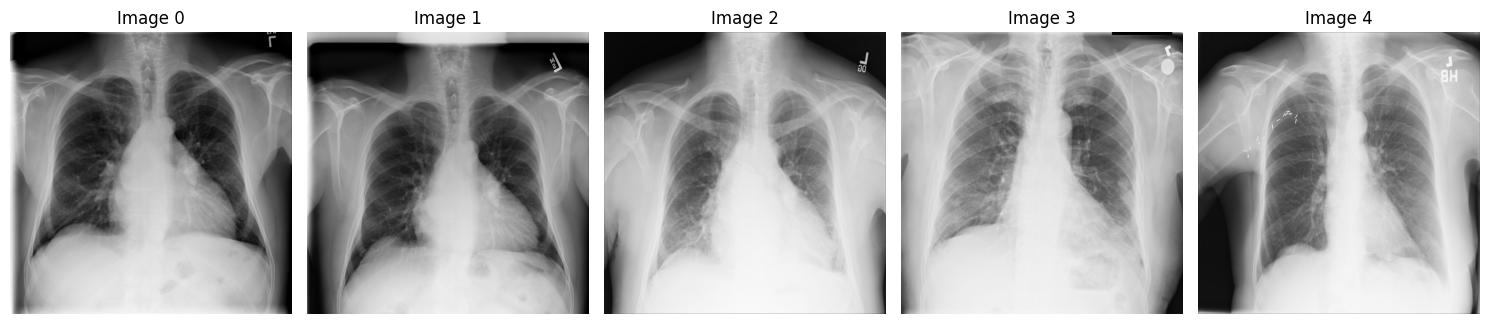

In [15]:
if dataExploration:
  if not dataLoad:
    # Add an image_path column to the DataFrame (by default this column doesnt exists)
    images_paths = {
        os.path.basename(x): x for x in
            glob(os.path.join('.', 'datasets', 'images', '*.png'))
    }
    csv_exploration['image_path'] = csv_exploration['Image Index'].map(images_paths.get)


  plt.figure(figsize=(15, 5))
  for i in range (0,5):
      img = cv2.imread(csv_exploration["image_path"].iloc[i])
      plt.subplot(1, 5, i+1)
      plt.imshow(img)
      plt.title(f"Image {i}")
      plt.axis('off')

  plt.tight_layout()
  plt.show()

# Data Preprocessing

The following section is destinated to Preprocess the data, most of this section is gonna be skiped is the variable **dataLoad = True**

Preprocess the data is very important for these type of datasets, and also makes easier to the model to learn

## Labels Maping
To make it easier for the model to work with, the label data is converted into a more structured format. For each label, a new column is created that contains a 1 if that category is present in the image, or a 0 if it is not. This way, each image is represented by a series of indicators summarizing its characteristics.

Finally, a few examples of the result are displayed, along with a brief summary of how often each label appears. This helps provide a general understanding of the type of data available and how it's distributed.

In [16]:
if not dataLoad:
  csv = pd.read_csv(dataset_path)

  # Add each label as a column and set 1 if the label was assigned to the image;
  # otherwise, set 0.
  for label in all_labels:
      csv[label] = csv['Finding Labels'].map(lambda finding_labels: 1 if label in finding_labels else 0)

  if dataExploration:
    csv.sample(3)

## Undersampling
Its more common to have healthy patients than a sick one, and there are a very rare diseases

### Undersampling of No_Findings
To the complete dataset we are kepping only the 10% of the total **Healthy** rows. Because is the most common class

In [17]:
if not dataLoad:

  # Splits healthy vs. sick
  df_healthy = csv[csv['No Finding'] == 1]

  df_disease = csv[csv['No Finding'] == 0]

  # Undersample: keeps only the 10% of the healthy ones
  df_healthy_down = resample(
      df_healthy,
      replace=False,
      n_samples=int(len(df_healthy) * 0.10),
      random_state=42
  )

  # Combine the healthy df with the sick df
  df_balanced = pd.concat([df_healthy_down, df_disease]).reset_index(drop=True)


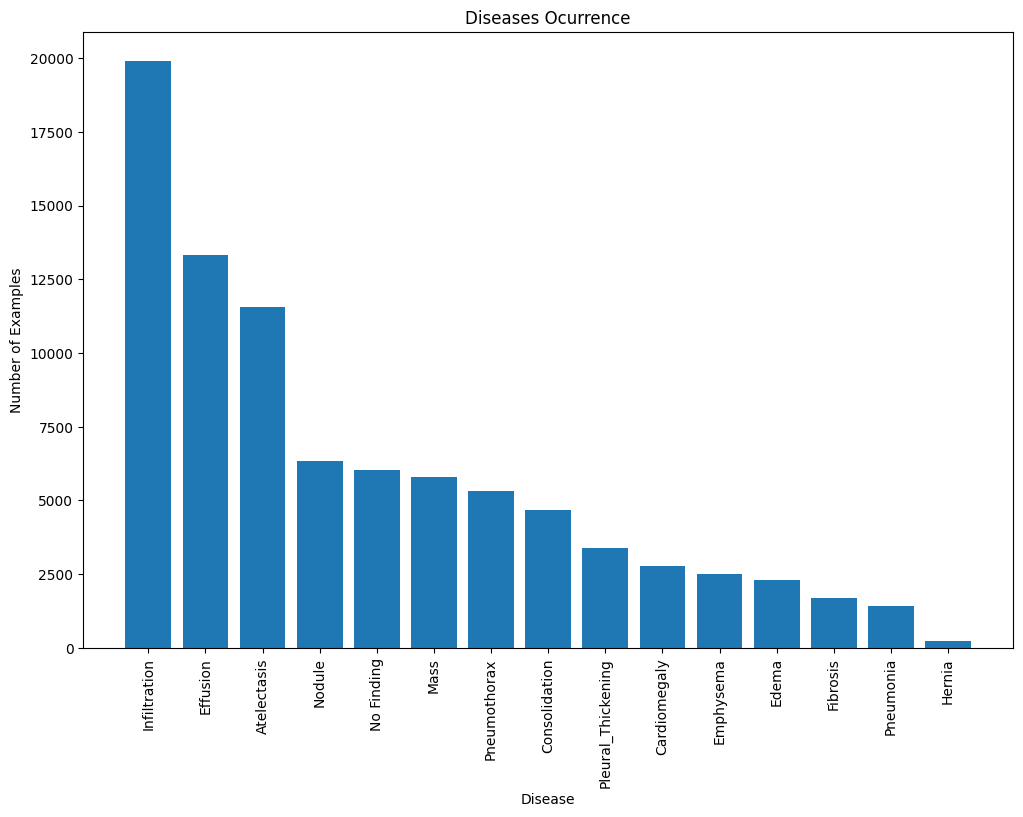

In [18]:
if not dataLoad:
  if dataExploration:
    # Sum of occurrences
    label_counts = df_balanced[all_labels].sum().sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Diseases Ocurrence")
    ax1.set_ylabel("Number of Examples")
    ax1.set_xlabel("Disease")

### Undersampling Infiltration


To the complete dataset we are kepping only the 15% of the total Infiltration rows. Because is one of the most common class

In [19]:
if not dataLoad:

  # Splits the case with ONLY infiltration
  df_infiltration = df_balanced[
      (df_balanced['Infiltration'] == 1) &
      (df_balanced[all_labels].drop(columns='Infiltration').sum(axis=1) == 0)
  ]

  df_other_labels = df_balanced[
      (df_balanced['Infiltration'] != 1) |
      (df_balanced[all_labels].drop(columns='Infiltration').sum(axis=1) > 0)
  ]

  # Undersample: keeps only the 15 % of infiltration
  df_infiltration_down = resample(
      df_infiltration,
      replace=False,
      n_samples=int(len(df_infiltration) * 0.15),
      random_state=42
  )

  # Combines the infiltration df with the rest of the df
  df_balanced_2 = pd.concat([df_infiltration_down, df_other_labels]).reset_index(drop=True)

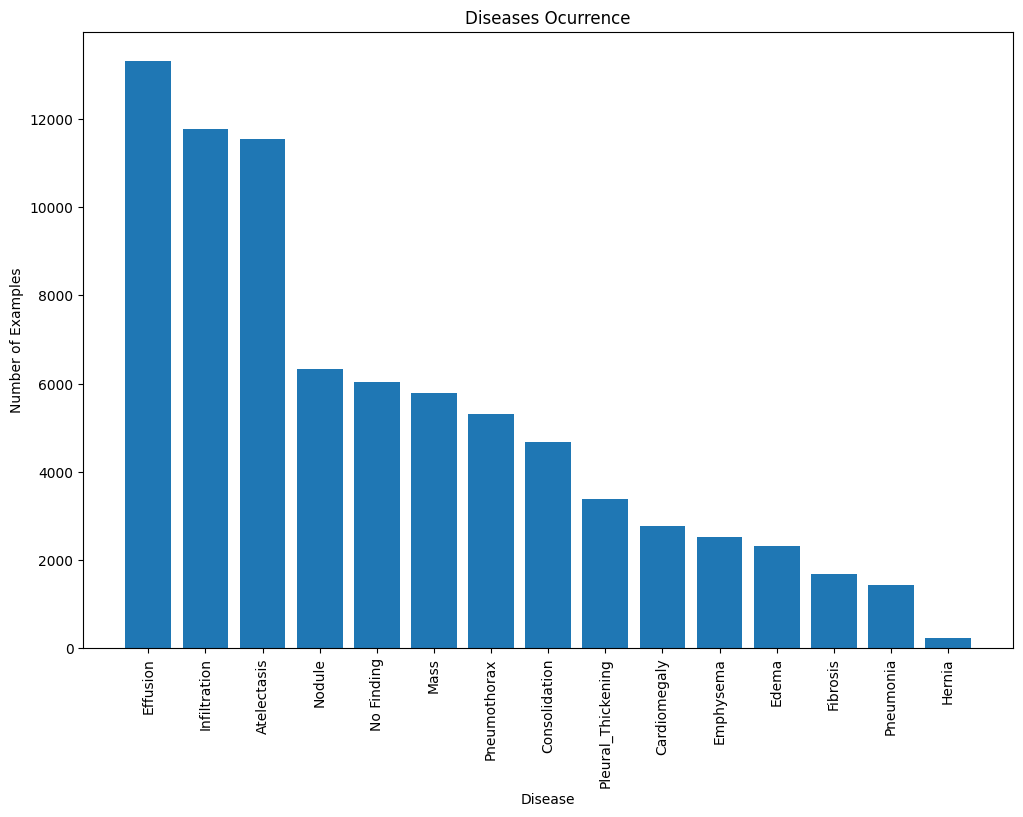

In [20]:
if not dataLoad:
  if dataExploration:
    # Sum of occurrences
    label_counts = df_balanced_2[all_labels].sum().sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Diseases Ocurrence")
    ax1.set_ylabel("Number of Examples")
    ax1.set_xlabel("Disease")

### Undersampling Effusion
To the complete dataset we are kepping only the 50% of the total Effusion rows. Because is one of the most common class

In [21]:
if not dataLoad:

  # Splits the case with ONLY Effusion
  df_efussion = df_balanced_2[
      (df_balanced_2['Effusion'] == 1) &
      (df_balanced_2[all_labels].drop(columns='Effusion').sum(axis=1) == 0)
  ]

  df_other_labels = df_balanced_2[
      (df_balanced_2['Effusion'] != 1) |
      (df_balanced_2[all_labels].drop(columns='Effusion').sum(axis=1) > 0)
  ]

  # Undersample: keeps only the 50 % of Effusion
  df_efussion_down = resample(
      df_efussion,
      replace=False,
      n_samples=int(len(df_efussion) * 0.50),
      random_state=42
  )

  # Combines the Effusion df with the rest of the df
  df_balanced_3 = pd.concat([df_efussion_down, df_other_labels]).reset_index(drop=True)

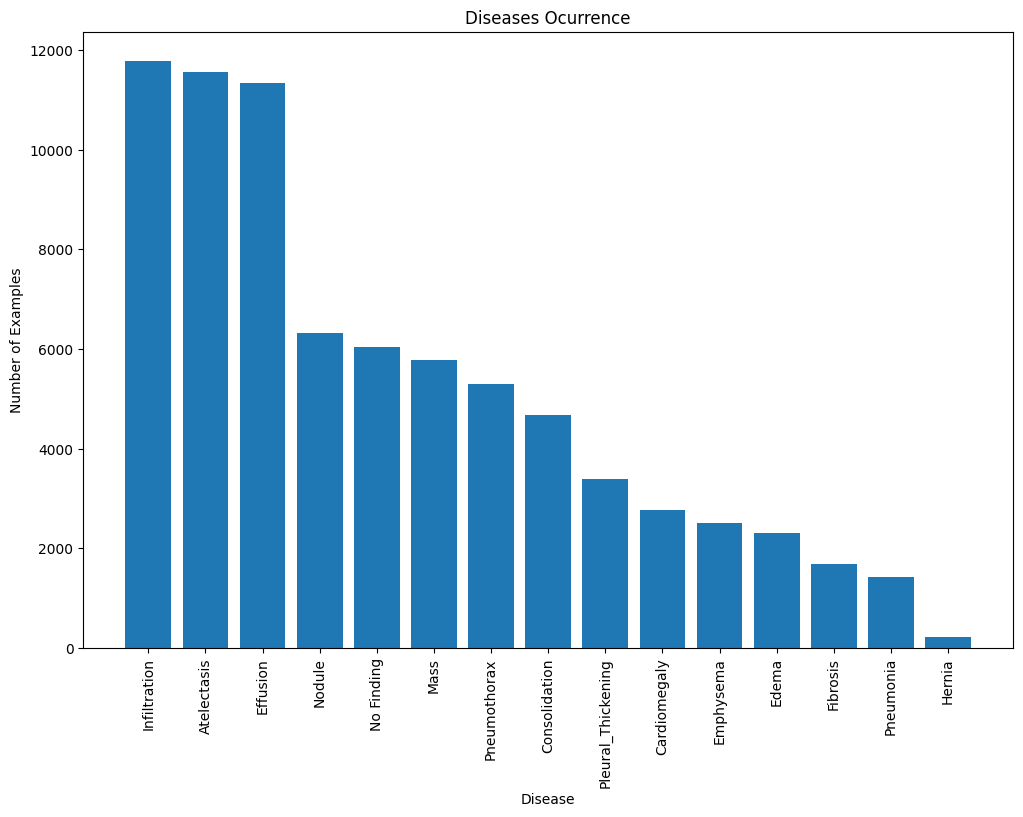

In [22]:
if not dataLoad:
  if dataExploration:
    # Sum of occurrences
    label_counts = df_balanced_3[all_labels].sum().sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Diseases Ocurrence")
    ax1.set_ylabel("Number of Examples")
    ax1.set_xlabel("Disease")

### Undersampling Atelectasis
To the complete dataset we are kepping only the 50% of the total Atelectasis rows. Because is one of the most common class

In [23]:
if not dataLoad:

  # Splits the case with ONLY Atelectasis
  df_atelectasis = df_balanced_3[
      (df_balanced_3['Atelectasis'] == 1) &
      (df_balanced_3[all_labels].drop(columns='Atelectasis').sum(axis=1) == 0)
  ]

  df_other_labels = df_balanced_3[
      (df_balanced_3['Atelectasis'] != 1) |
      (df_balanced_3[all_labels].drop(columns='Atelectasis').sum(axis=1) > 0)
  ]

  # Undersample: keeps only the 50 % of Atelectasis
  df_atelectasis_down = resample(
      df_efussion,
      replace=False,
      n_samples=int(len(df_efussion) * 0.50),
      random_state=42
  )

  # Combines the Atelectasis df with the rest of the df
  df_balanced_4 = pd.concat([df_efussion_down, df_other_labels]).reset_index(drop=True)

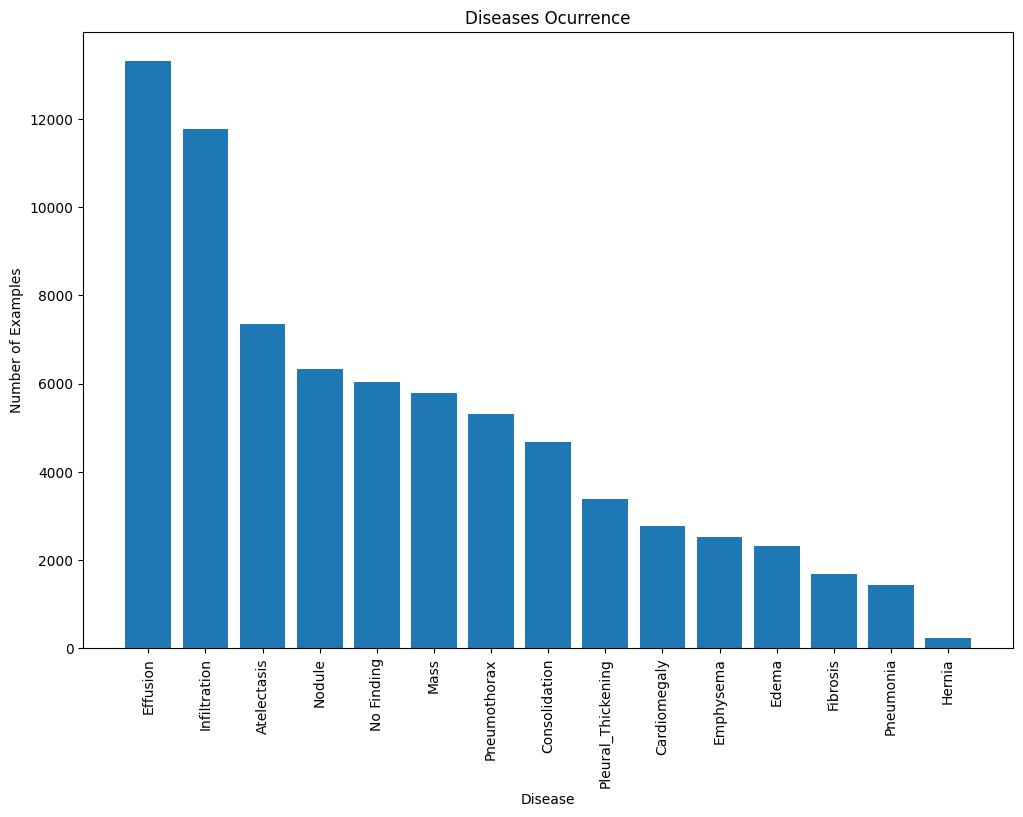

In [24]:
if not dataLoad:
  if dataExploration:
    # Sum of occurrences
    label_counts = df_balanced_4[all_labels].sum().sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Diseases Ocurrence")
    ax1.set_ylabel("Number of Examples")
    ax1.set_xlabel("Disease")

### Summary
All these undersamplings are specified on the following table:
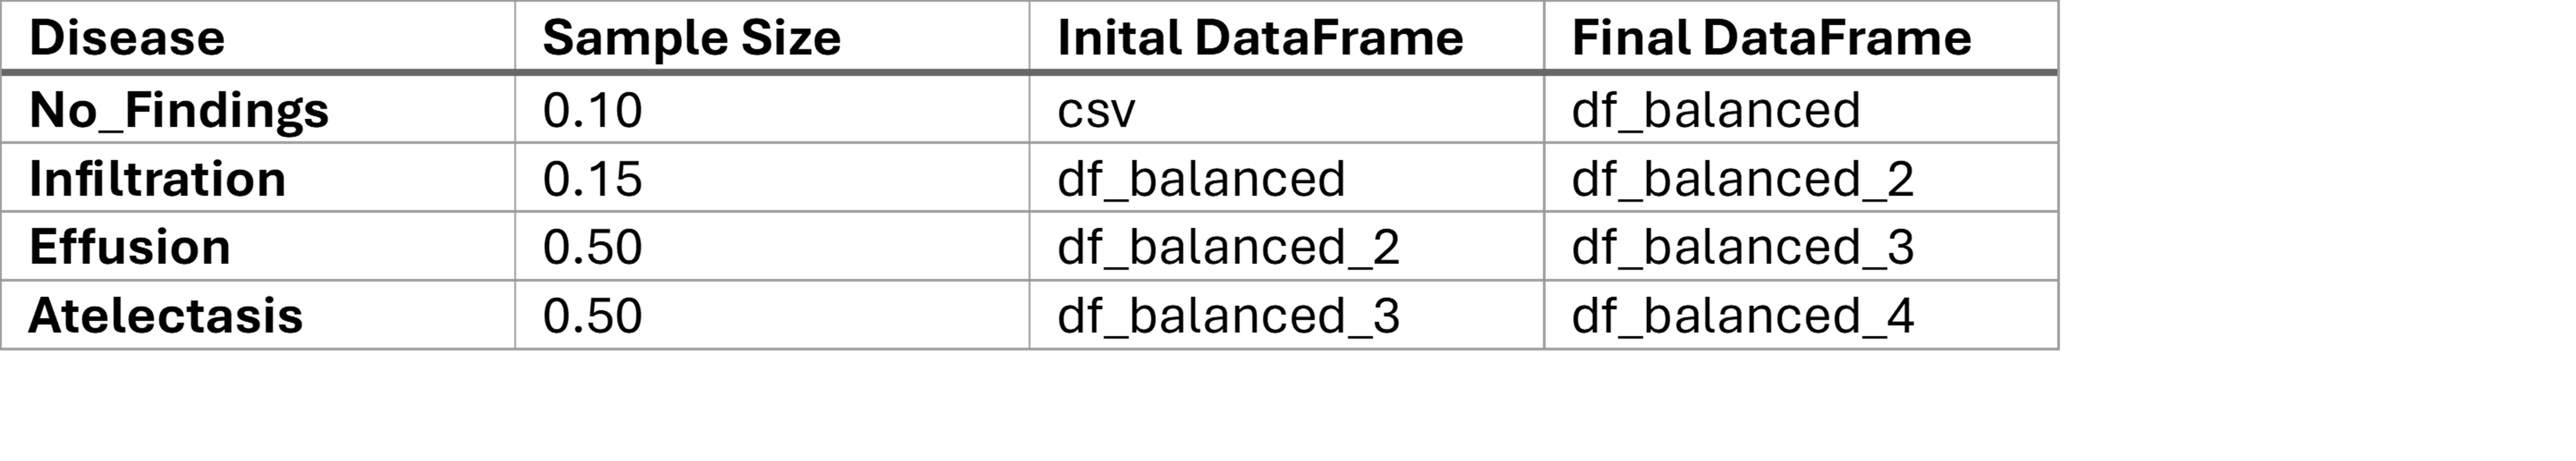

## Create a column containing the diseases as a list
First, the label information is cleaned by removing any indication that an image shows no findings, since this doesn’t provide useful information for the model. After this cleaning, all labels that appear in the dataset are extracted, regardless of how many times they occur.

Once the sampled and balanced dataset is obtained, a new column called "disease_vec" is created. This column contains a binary vector for each image, representing the presence or absence of each possible medical label.

To construct this vector, the values of all the columns corresponding to the labels (i.e., the ones that were previously generated with 1s and 0s for each finding) are taken and grouped into an array. This way, each row has a vector that summarizes all the diseases associated with the image, in a format that is directly useful for training multi-label classification models.


In [25]:
if not dataLoad:
  all_labels.remove('No Finding')

  df_balanced_3.drop('No Finding', axis=1, inplace=True)

  df_balanced_3['disease_vec'] = df_balanced_3.apply(lambda x: x[all_labels].astype(int).values, axis=1)

  if dataExploration:
    df_balanced_3[all_labels + ['disease_vec']]

## Patient Info
The tabular data needed by the model is gonna be preprocessed.

### Age
Normalizing the age to have values btw 0-1

In [26]:
if not dataLoad:
  df_balanced_3["normalized_age"] = (df_balanced_3["Patient Age"] - df_balanced_3["Patient Age"].min()) / (df_balanced_3["Patient Age"].max() - df_balanced_3["Patient Age"].min())

  if dataExploration:
    df_balanced_3.head()

### Gender
Changing the value of the column "Patient Age" to the following format:

Male = 0

Female = 1

Is more convenient for the model have the data on this format

In [27]:
if not dataLoad:
  df_balanced_3["Patient Gender"] = df_balanced_3.apply(lambda x: 0 if x["Patient Gender"] == 'M' else 1, axis=1)

  if dataExploration:
    df_balanced_3.head()

### View Position
Changing the value of the column "View Potition" to the following format:

PA = 0

AP = 1

Is more convenient for the model have the data on this format

In [28]:
if not dataLoad:
  df_balanced_3["View Position"] = df_balanced_3.apply(lambda x: 0 if x["View Position"] == 'PA' else 1, axis=1)

  if dataExploration:
    df_balanced_3.head()

### Transform this features as a List


In [29]:
if not dataLoad:
  df_balanced_3["patient_info"] = df_balanced_3[["normalized_age", "Patient Gender", "View Position"]].values.tolist()

  if dataExploration:
    df_balanced_3.head()

## Final DataSet

The final dataset is showed on the cell bellow

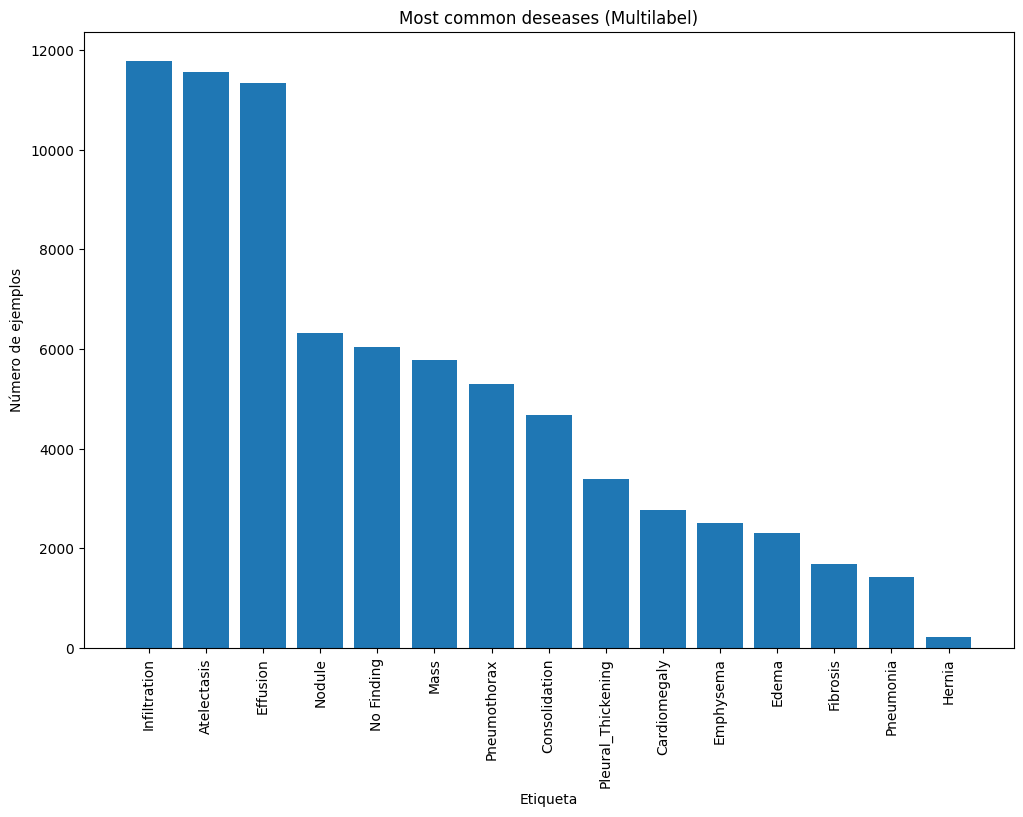

In [30]:
if not dataLoad:
  if dataExploration:
    # Suma of the occurences of each diseases
    label_counts = df_balanced_3[all_labels].sum().sort_values(ascending=False)

    no_finding_count = (df_balanced_3[all_labels].sum(axis=1) == 0).sum()

    label_counts["No Finding"] = no_finding_count

    label_counts = label_counts.sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Most common deseases (Multilabel)")
    ax1.set_ylabel("Número de ejemplos")
    ax1.set_xlabel("Etiqueta")

## Split the dataset
At this stage, the balanced dataset is divided into three subsets:
- **Training (train_df):** 72% of the complete dataset
- **Validation (validation_df):** 8% of the complete dataset (10% of the training dataset)
- **Test (test_df):** 20% of the complete dataset

To maintain a similar distribution of labels in each partition, the stratify option is used, which groups the samples based on the first few letters of the diagnostic labels. This helps ensure that the class proportions are not distorted too much in the test subset.


Finally, the number of images in each subset is printed, allowing for a quick check to confirm that the splits were made correctly.

In [31]:
if not dataLoad:
  df_final = df_balanced_3.sample(frac=0.9, random_state=42)

  import cv2
  import matplotlib.pyplot as plt
  import os
  from glob import glob


  # Add an image_path column to the DataFrame
  images_paths = {
      os.path.basename(x): x for x in
          glob(os.path.join('.', 'datasets', 'data', 'images', '*.png'))
  }

  df_final['image_path'] = df_final['Image Index'].map(images_paths.get)

  from sklearn.model_selection import train_test_split
  train_df, test_df = train_test_split(df_final,
                                    test_size = testSize,
                                    random_state = 86196,
                                    stratify = df_final['Finding Labels'].map(lambda x: x[:4]))

  train_df, validation_df = train_test_split(train_df,
                                    test_size = 0.10,
                                    random_state = 47941,
                                    stratify = train_df['Finding Labels'].map(lambda x: x[:4])) #why finding labels and not disease_vec

  if dataExploration:
    print('Train:', train_df.shape[0], 'Validation:', validation_df.shape[0], 'Test:', test_df.shape[0])

Train: 30910 Validation: 3435 Test: 8587


## Training dataFrame Preprocessing
The training dataset needs more preprocessing, this preprocessing was not performed on the previous cells, due a possible data leackege (when the validation data is mixed with the training data)

### Vertical Flip
Added a vertical flip to the images that has less than 3000 ocurrences. This process duplicates the number of ocurrences for these minority diseases.

This can be done because this transformation doesnt add distortion to the lungs anatomy

In [32]:
if not dataLoad:
  threshold = 3000

  label_counts = train_df[all_labels].sum()

  minority_classes = label_counts[label_counts < threshold].index.tolist()

  df_minor_only = train_df[
      (train_df[minority_classes].sum(axis=1) > 0) &  # has minority classes
      (train_df[[c for c in all_labels if c not in minority_classes]].sum(axis=1) == 0)  # and any mayority
  ].copy()

  df_minor_only["flip_vertical"] = True

  df_rest = train_df.copy()
  df_rest["flip_vertical"] = False

  train_df_2= pd.concat([df_rest, df_minor_only]).reset_index(drop=True)

  if dataExploration:
    train_df_2

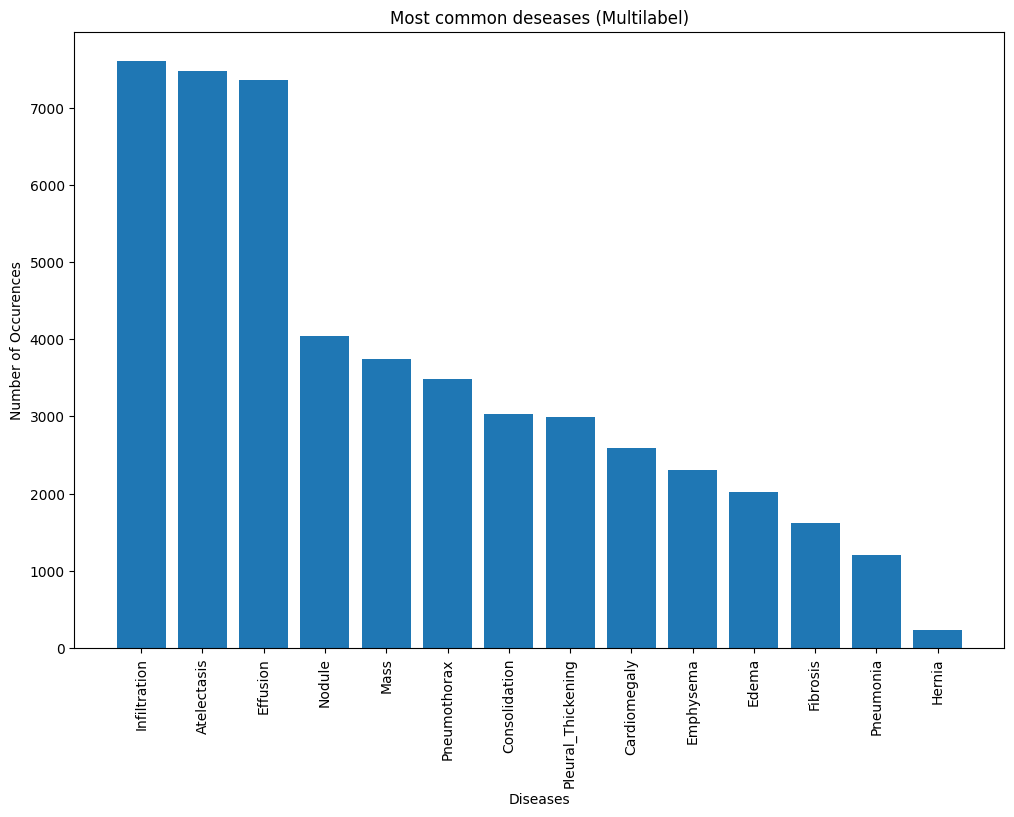

In [33]:
if not dataLoad:
  if dataExploration:
    # Sum of each desease
    label_counts = train_df_2[all_labels].sum().sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Most common deseases (Multilabel)")
    ax1.set_ylabel("Number of Occurences")
    ax1.set_xlabel("Diseases")

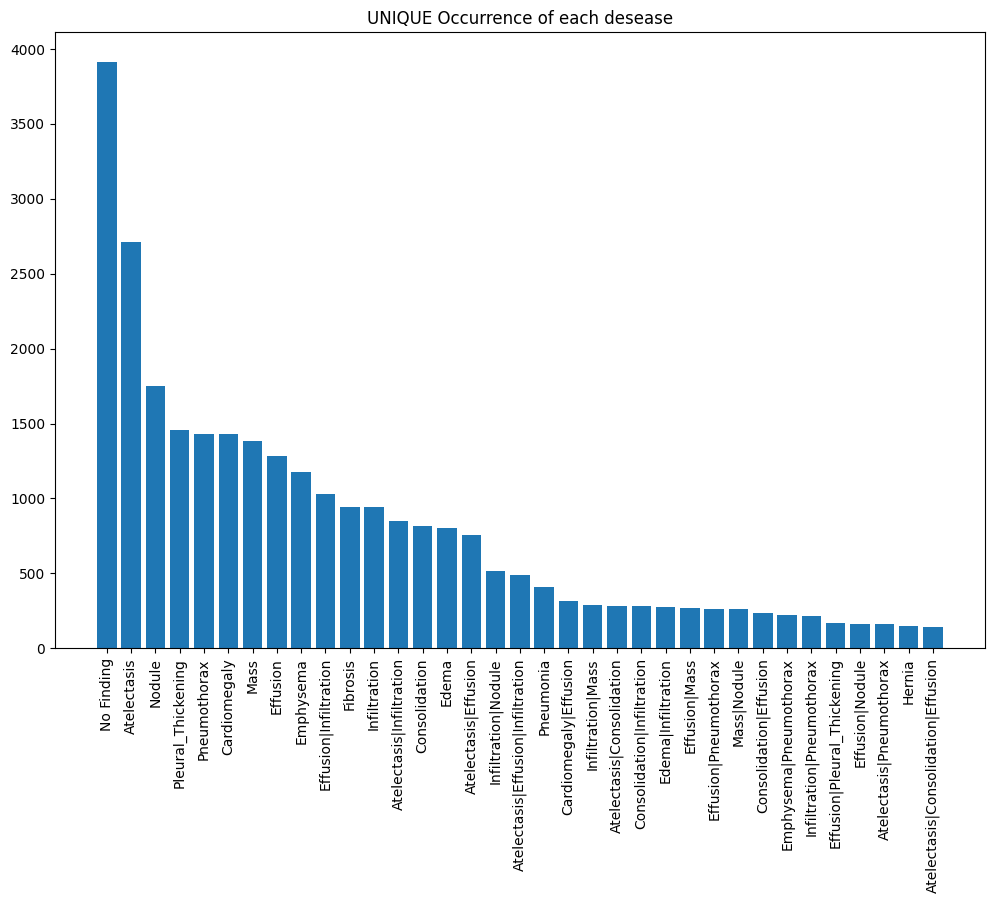

In [34]:
if not dataLoad:
  if dataExploration:
    label_counts = train_df_2['Finding Labels'].value_counts()[:35]

    fig, ax1 = plt.subplots(1,1,figsize = (12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)

    _ = ax1.set_xticklabels(label_counts.index, rotation = 90)

    ax1.set_title("UNIQUE Occurrence of each desease")

    df_balanced_3.head(5)

### Oversampling training dataset

The diseases with 1500 or less occurences are gonna be added N times to a new dataset in order to reach the threshold

In [35]:
if not dataLoad:
  from sklearn.utils import resample

  threshold = 1500


  label_counts = train_df_2[all_labels].sum()
  minority_classes = label_counts[label_counts < threshold].index.tolist()
  majority_classes = label_counts[label_counts >= threshold].index.tolist()

  df_augmented_list = []

  for label in minority_classes:
      count = label_counts[label]
      n_to_add = threshold - count
      if n_to_add <= 0:
          continue

      # Filters only the rows with minority classes (without mayority ones)
      df_candidates = train_df_2[
          (train_df_2[label] == 1) &
          (train_df_2[majority_classes].sum(axis=1) == 0)
      ]

      if len(df_candidates) == 0:
          continue  # there are not good cantidates for this class

      # Resample until reach the threshold
      df_oversampled = resample(df_candidates,
                                replace=True,
                                n_samples=n_to_add,
                                random_state=42)

      df_augmented_list.append(df_oversampled)

  # Combines the oversemple dataset with the old one
  train_df_3 = pd.concat([train_df_2] + df_augmented_list).sample(frac=1).reset_index(drop=True)

  if dataExploration:
    # verify the new distribution
    label_counts_final = train_df_3[all_labels].sum()
    print(label_counts_final)

Hernia                1500
Nodule                4043
Fibrosis              1620
Edema                 2019
Cardiomegaly          2585
Effusion              7359
Pneumothorax          3488
Pleural_Thickening    2987
Consolidation         3036
Emphysema             2300
Pneumonia             1500
Mass                  3741
Atelectasis           7482
Infiltration          7605
dtype: int64


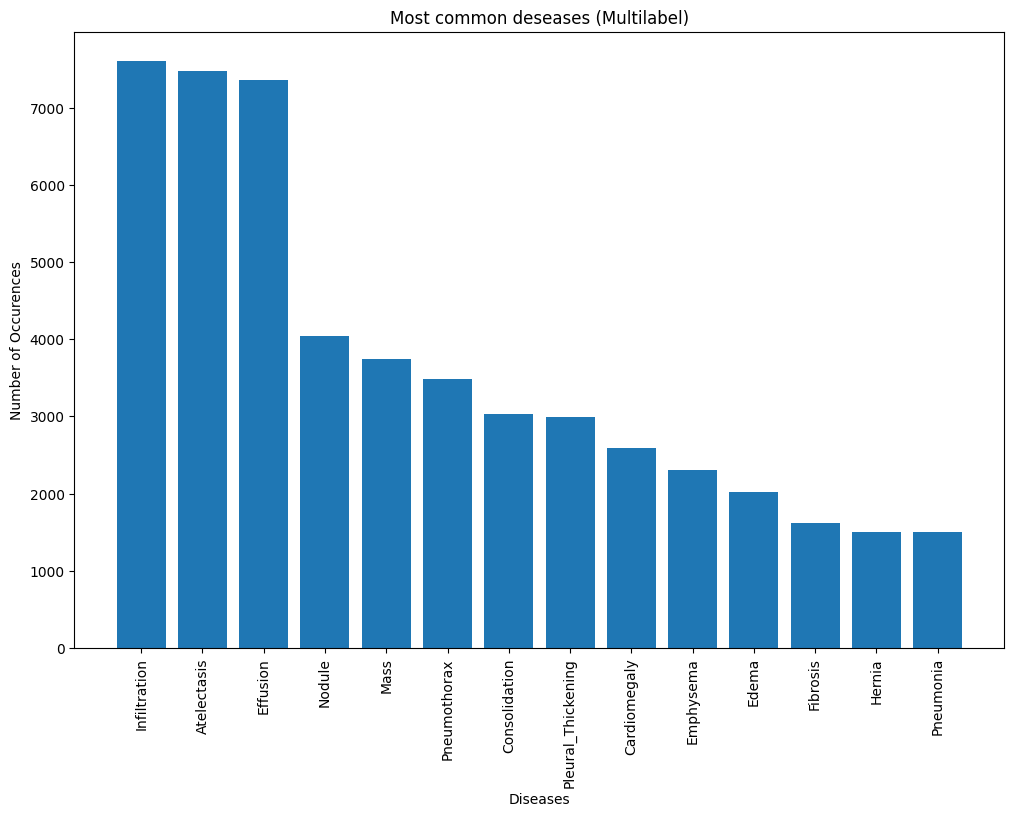

In [36]:
if not dataLoad:
  if dataExploration:
    # Sum of each desease
    label_counts = train_df_3[all_labels].sum().sort_values(ascending=False)

    # Graph
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts.values)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)
    ax1.set_xticklabels(label_counts.index, rotation=90)

    ax1.set_title("Most common deseases (Multilabel)")
    ax1.set_ylabel("Number of Occurences")
    ax1.set_xlabel("Diseases")

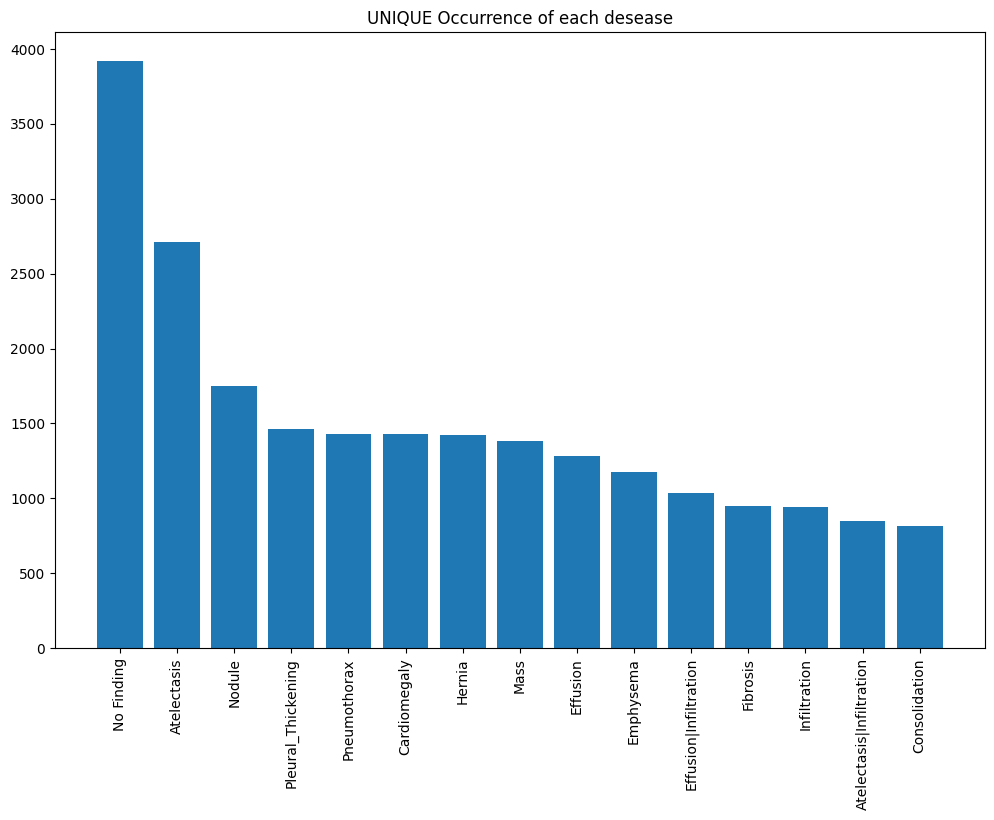

In [37]:
if not dataLoad:
  if dataExploration:
    label_counts = train_df_3['Finding Labels'].value_counts()[:15]

    fig, ax1 = plt.subplots(1,1,figsize = (12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)

    _ = ax1.set_xticklabels(label_counts.index, rotation = 90)

    ax1.set_title("UNIQUE Occurrence of each desease")

    train_df_2.head(5)

### Under Sampling No Findings on Training Dataset

No Findings stills have a high number of occurences, we are kepping only the 25%

In [38]:
if not dataLoad:
  # split healthy vs. sick
  df_healthy = train_df_3[train_df_3[all_labels].sum(axis=1) == 0]
  df_disease = train_df_3[train_df_3[all_labels].sum(axis=1) > 0]

  # Undersample: keeps only the 25% of the healthy ones
  df_healthy_down = resample(
      df_healthy,
      replace=False,
      n_samples=int(len(df_healthy) * 0.25),
      random_state=42
  )

  # combines the 2 datasets
  train_df_4 = pd.concat([df_healthy_down, df_disease]).reset_index(drop=True)

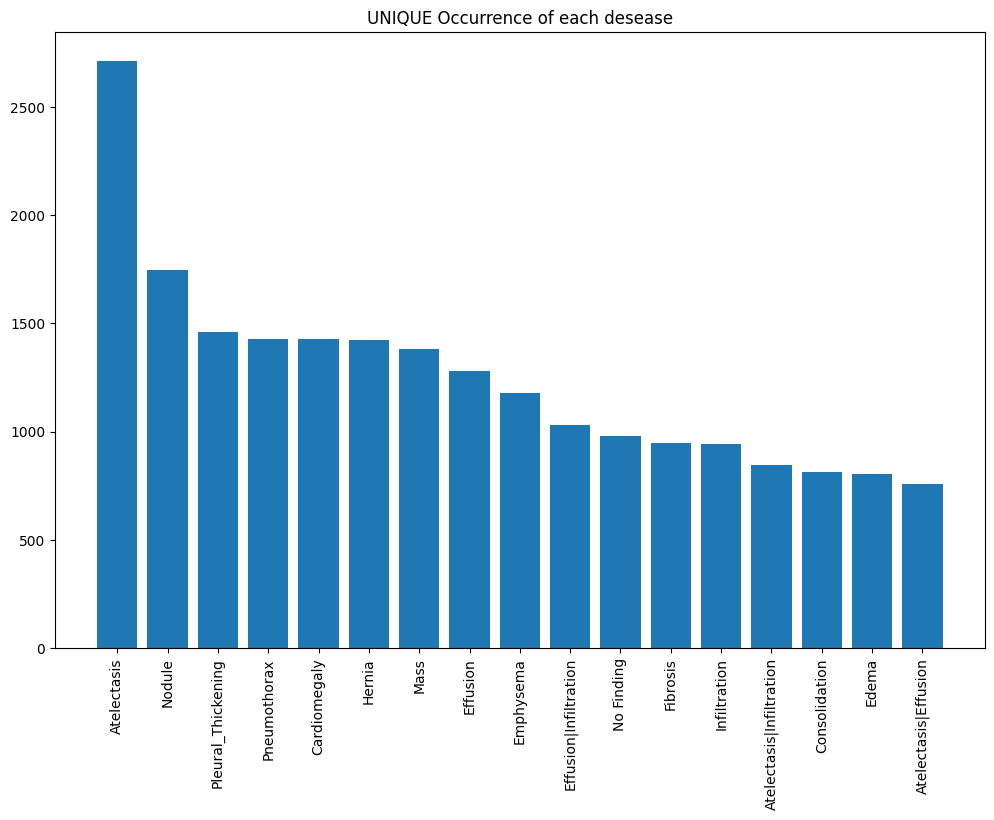

In [39]:
if not dataLoad:
  if dataExploration:
    label_counts = train_df_4['Finding Labels'].value_counts()[:17]

    fig, ax1 = plt.subplots(1,1,figsize = (12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)

    _ = ax1.set_xticklabels(label_counts.index, rotation = 90)

    ax1.set_title("UNIQUE Occurrence of each desease")

    train_df_4.head(5)

### UnderSampling Atelectasis
No Findings stills have a high number of occurences, we are kepping only the 50%

In [40]:
if not dataLoad:
  from sklearn.utils import resample

  # Splits the rows that has only Atelectasis
  df_atelectasis = train_df_4[
      (train_df_4['Atelectasis'] == 1) &
      (train_df_4[all_labels].drop(columns='Atelectasis').sum(axis=1) == 0)
  ]

  df_other_labels = train_df_4[
      (train_df_4['Atelectasis'] != 1) |
      (train_df_4[all_labels].drop(columns='Atelectasis').sum(axis=1) > 0)
  ]

  # Undersample: keeps onlt the 50% of the Atelectasis
  df_atelectasis_down = resample(
      df_atelectasis,
      replace=False,
      n_samples=int(len(df_atelectasis) * 0.50),
      random_state=42
  )


  # Combines the 2 datasets
  train_df_final = pd.concat([df_atelectasis_down, df_other_labels]).reset_index(drop=True)

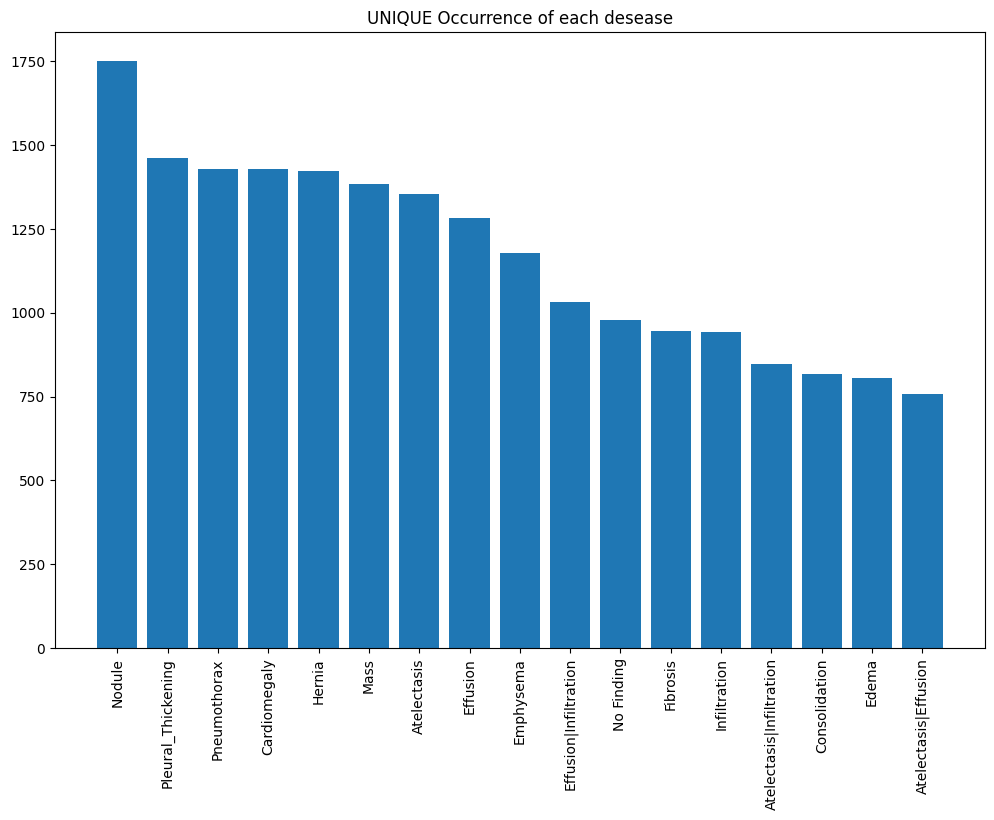

In [41]:
if not dataLoad:
  if dataExploration:
    label_counts = train_df_final['Finding Labels'].value_counts()[:17]

    fig, ax1 = plt.subplots(1,1,figsize = (12, 8))

    ax1.bar(np.arange(len(label_counts)) + 0.5, label_counts)

    ax1.set_xticks(np.arange(len(label_counts)) + 0.5)

    _ = ax1.set_xticklabels(label_counts.index, rotation = 90)

    ax1.set_title("UNIQUE Occurrence of each desease")

    train_df_final.head(5)

### Summary
All the preprocess process is specified on the following table:
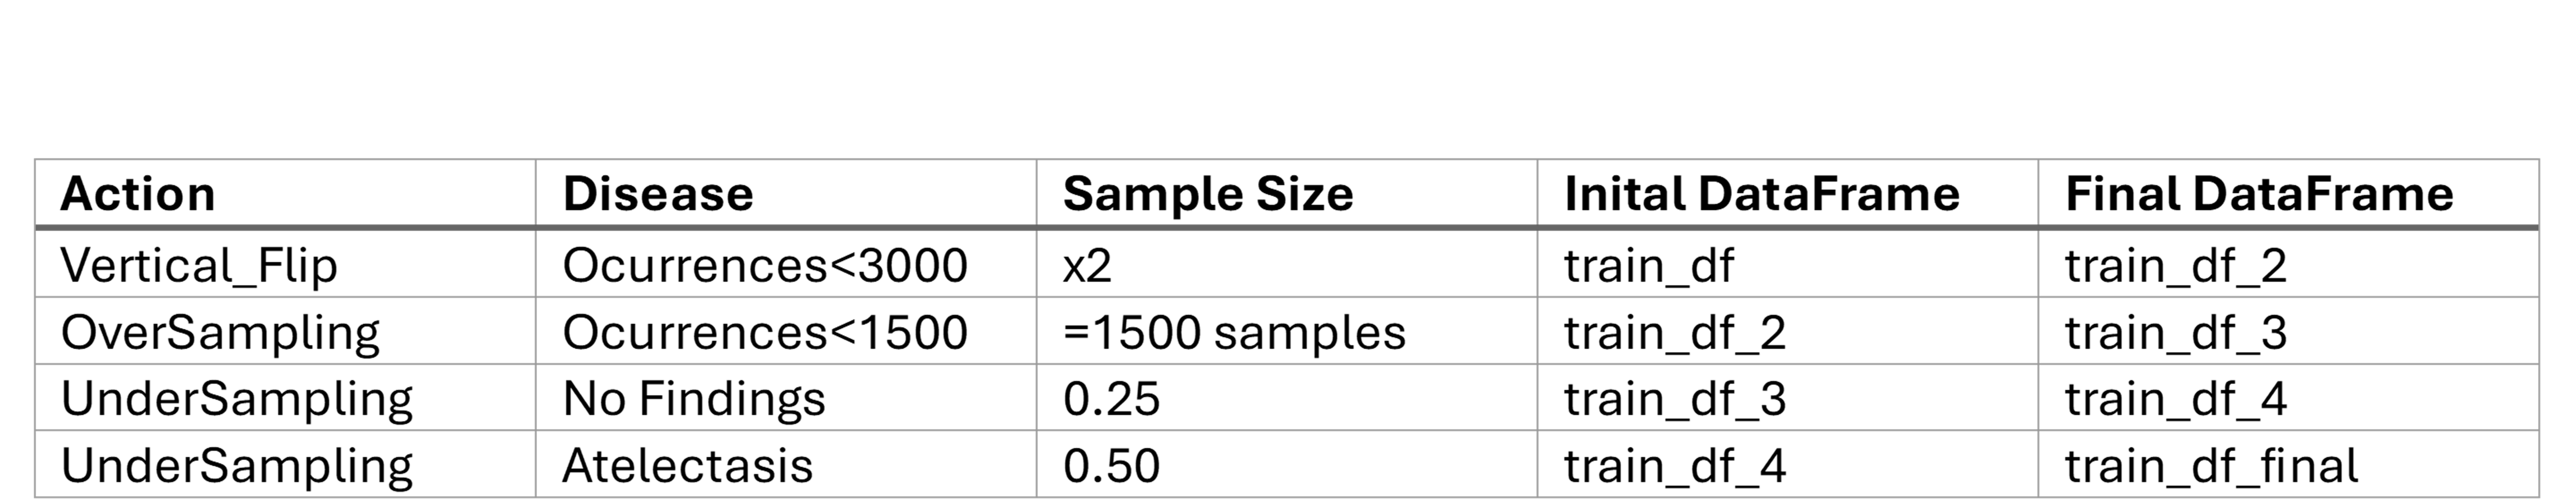

## Saving the DataSet
After the whole process of data preproccesing, we remove the unnecesary images and after that, the dataset is stored on google drive

The folder imported to google drive was downloaded and uploaded to our [Hugging Face Repository](https://huggingface.co/datasets/Carlos56g/ChestXRay15GB)

The structure of the dataset stored on Google Drive is (14.5 GB):
- dataframes
  - data
    - dataframes
      - final_df.csv
      - test_df.csv
      - train_df.csv
      - validation_df.csv
    - images
      - #####_###.png


In [42]:
if not dataLoad:
  image_column = 'Image Index'

  # Gets all the images
  valid_images = set(df_final[image_column].values)

  inital_images_train = set(train_df[image_column].values)

  final_images_train = set(train_df_final[image_column].values)

  #Gets all the images deleted on the data Preprocessing for the training df
  imagesDelete=inital_images_train.difference(final_images_train)


  # Folder where are all the images
  image_dir = 'datasets/data/images/'

  #Deletes all the images stored on the df_final
  for image_name in os.listdir(image_dir):
      if image_name not in valid_images:
          os.remove(os.path.join(image_dir, image_name))

  #Deletes all the images stored imagesDelete
  for image_name in os.listdir(image_dir):
      if image_name in imagesDelete:
          os.remove(os.path.join(image_dir, image_name))


  drive.mount('/content/drive')

  # direction to google drive for the images
  imagesDestination = '/content/drive/My Drive/datasets/data/images/'

  # copy all the image folder
  shutil.copytree('datasets/data/images/', imagesDestination, dirs_exist_ok=True)


  #creating a folder to store the dataframes
  SAVED_DATAFRAMES_DIR = Path("datasets/data/dataframes")
  SAVED_DATAFRAMES_DIR.mkdir(parents=True, exist_ok=True)


  #save the dataframes
  df_final.to_csv(SAVED_DATAFRAMES_DIR / "final_df.csv", index=False)

  train_df_final.to_csv(SAVED_DATAFRAMES_DIR / "train_df.csv", index=False)
  validation_df.to_csv(SAVED_DATAFRAMES_DIR / "validation_df.csv", index=False)
  test_df.to_csv(SAVED_DATAFRAMES_DIR / "test_df.csv", index=False)


  #direction on google drive to save the dataframes
  dataFramesDestination = '/content/drive/My Drive/datasets/data/dataframes'

  # copy the dataframe folder to Google Drive
  shutil.copytree(SAVED_DATAFRAMES_DIR, dataFramesDestination, dirs_exist_ok=True)

MessageError: Error: credential propagation was unsuccessful

## Data Argumentation

In this step, we create 2 dataloader object and apply data augmentations to improve model generalization.

The augmentations include:

**train_transform:**

This transformation pipeline is used during training to augment the dataset and help the model generalize better.
- Converting images to tensors with pixel values scaled between 0 and 1.
- Random cropping (using 90% of the original image size) to introduce spatial variation.
- Resizing to a fixed size defined by IMAGE_SIZE (e.g., 640×640) for input consistency.
- Applying random affine transformations with slight rotation (±7 degrees) and translation (up to 6%) to simulate different viewpoints.
- Applying Gaussian blur with kernel size 3 and sigma between 0.2 and 1.5 to mimic noise — applied with 40% probability.
- Normalizing images using ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) to standardize the input.

**val_test_transform:**

This transformation pipeline is used during validation and testing, where consistency and input standardization are prioritized over augmentation.
- Converting images to tensors with pixel values scaled between 0 and 1.
- Random cropping (90% of the original image size) to reduce edge artifacts and maintain consistency.
- Resizing to IMAGE_SIZE to match model input dimensions.
- Normalizing using the same ImageNet statistics to keep inference consistent with training.

In [ ]:
IMAGE_SIZE = (imageDimension, imageDimension)

train_transform = transforms.Compose([
    transforms.ToTensor(), # image values will be scaled between 0 and 1
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomCrop(size=(224, 224)),
    transforms.RandomAffine(degrees=7, translate=(0.060, 0.060)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.2, 1.5))
    ], p=0.3),  # Aplica GaussianBlur al 30% de las imágenes
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])


val_test_transform = transforms.Compose([
    transforms.ToTensor(), # image values will be scaled between 0 and 1
    transforms.Resize((224,224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, path_column, patient_info, y_column, transform=None):
        self.dataframe = dataframe
        self.path_column = path_column
        self.patient_info = patient_info
        self.y_column = y_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
            row = self.dataframe.iloc[index]
            image_path = row[self.path_column]
            label = row[self.y_column]
            flip_vertical = row.get("flip_vertical", False)

            image = Image.open(image_path).convert("RGB")

            if flip_vertical: #Only the train dataloader has vertical Flip
                image = TF.hflip(image)

            if self.transform:
                image = self.transform(image)

            label = torch.tensor(label, dtype=torch.float32)

            if self.patient_info:
                tabular_data = torch.tensor(row[self.patient_info], dtype=torch.float32)
            else:
                tabular_data = torch.zeros(3, dtype=torch.float32)

            return image, tabular_data, label


class ChestXRayDatasetValTrain(Dataset):
    def __init__(self, dataframe, path_column, patient_info, y_column, transform=None):
        self.dataframe = dataframe
        self.path_column = path_column
        self.patient_info = patient_info
        self.y_column = y_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
            row = self.dataframe.iloc[index]
            image_path = row[self.path_column]
            label = row[self.y_column]

            image = Image.open(image_path).convert("RGB")

            label = torch.tensor(label, dtype=torch.float32)

            if self.transform:
                image = self.transform(image)

            if self.patient_info:
                tabular_data = torch.tensor(row[self.patient_info], dtype=torch.float32)
            else:
                tabular_data = torch.zeros(3, dtype=torch.float32)

            return image, tabular_data, label

## Get Final Dataset (DataLoader)
A function is defined that takes a DataFrame, key columns, and batch size as input. This function uses the ChestXRayDataset class to create a dataset and then wraps it in a DataLoader, which handles delivering the data in batches with multiple processes in parallel to improve efficiency.

Three different datasets are created: one for training, one for validation, and one for testing. Each is configured with the same batch size.

Each one has his own data transformation

In [ ]:
def get_images_dataset_from_dataframe_train(dataframe: pd.DataFrame,
                                      path_column: str, patient_info: str, y_column: str,
                                      batch_size: int) -> DataLoader:
    dataset = ChestXRayDataset(dataframe, path_column, patient_info, y_column, transform=train_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return loader

def get_images_dataset_from_dataframe_val_test(dataframe: pd.DataFrame,
                                      path_column: str, patient_info: str, y_column: str,
                                      batch_size: int) -> DataLoader:
    dataset = ChestXRayDatasetValTrain(dataframe, path_column, patient_info, y_column, transform=val_test_transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    return loader


if sampleTest:
  train_df_final=train_df_final.sample(frac=sampleSize, random_state=42)
  validation_df=validation_df.sample(frac=sampleSize, random_state=42)
  test_df=test_df.sample(frac=sampleSize, random_state=42)



train_dataset = get_images_dataset_from_dataframe_train(
    dataframe=train_df_final,
    path_column="image_path",
    patient_info="patient_info",
    y_column="disease_vec",
    batch_size=batchSize,
)

validation_dataset = get_images_dataset_from_dataframe_val_test(
    dataframe=validation_df,
    path_column="image_path",
    patient_info="patient_info",
    y_column="disease_vec",
    batch_size=batchSize,
)

test_dataset = get_images_dataset_from_dataframe_val_test(
    dataframe=test_df,
    path_column="image_path",
    patient_info="patient_info",
    y_column="disease_vec",
    batch_size=batchSize,
)

## Visualize the images from the datasets

Shows the images for each dataLoader

In [ ]:
if dataExploration:
  NUM_BATCHES_TO_SHOW = 1
  NUM_IMAGES_TO_SHOW_BY_BATCH = 5

  i=0
  for index, (images, patient_info,  labels) in enumerate(train_dataset):
      if index >= NUM_BATCHES_TO_SHOW:
          break
      print(f"***Training BATCH {index+1} ***")
      for img, label in zip(images, labels):
          i=i+1
          # Convert the one-hot label tensor to a list
          label = label.tolist()
          # Get all the Finding Labels corresponding to this image using one-hot encoding.
          finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]
          if len(finding_labels) == 0:
              finding_labels = ["Healthy"]

          # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization
          img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")
          print("Std: ", img.std())
          print("Mean: ", img.mean())

          plt.figure(figsize=(5,5))
          plt.imshow(img_np)
          plt.title(", ".join(finding_labels))
          plt.colorbar()
          plt.show()
          if i>NUM_IMAGES_TO_SHOW_BY_BATCH:
            break

      print("----------------------------------------------------------------\n" * 10)

  i=0
  for index, (images, patient_info, labels) in enumerate(test_dataset):
      if index >= NUM_BATCHES_TO_SHOW:
          break
      print(f"***Test BATCH {index+1} ***")
      for img, label in zip(images, labels):
          i=i+1
          # Convert the one-hot label tensor to a list
          label = label.tolist()
          print(label)

          # Get all the Finding Labels corresponding to this image using one-hot encoding.
          finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]
          if len(finding_labels) == 0:
              finding_labels = ["Healthy"]

          # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization
          img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")
          print("Std: ", img.std())
          print("Mean: ", img.mean())

          plt.figure(figsize=(5,5))
          plt.imshow(img_np)
          plt.title(", ".join(finding_labels))
          plt.colorbar()
          plt.show()
          if i>NUM_IMAGES_TO_SHOW_BY_BATCH:
            break

      print("----------------------------------------------------------------\n" * 10)

  i=0
  for index, (images, patient_info, labels) in enumerate(validation_dataset):
      if index >= NUM_BATCHES_TO_SHOW:
          break
      print(f"***Validation BATCH {index+1} ***")
      for img, label in zip(images, labels):
          i=i+1
          # Convert the one-hot label tensor to a list
          label = label.tolist()
          print(label)

          # Get all the Finding Labels corresponding to this image using one-hot encoding.
          finding_labels = [all_labels[i] for i, l in enumerate(label) if l == 1]
          if len(finding_labels) == 0:
              finding_labels = ["Healthy"]

          # Convert image tensor (C, H, W) to (H, W, C) for plotting and scale to 0-255 for visualization
          img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")
          print("Std: ", img.std())
          print("Mean: ", img.mean())

          plt.figure(figsize=(5,5))
          plt.imshow(img_np)
          plt.title(", ".join(finding_labels))
          plt.colorbar()
          plt.show()
          if i>NUM_IMAGES_TO_SHOW_BY_BATCH:
            break

      print("----------------------------------------------------------------\n" * 10)

# Model
The following cells are used for model Train

We decided to use [DenseNet121](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.densenet121.html#torchvision.models.densenet121) for our backbone model

We used the Nvidia L4 (22.5 GB) for the training process

And the defaults parameters stored on the notebook

- testSize = 0.20
- epochs = 15
- batchSize = 160
- learningRate = 0.001
- BCEWithLogitsLoss = Loss Criterion

The training process was 5 hours long

All the training information and versions are stored on the [Git Hub repository]() and [One Drive Folder]()


## Clean Memory of the GPU
Just to have all the momory available for training

In [ ]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

## Model Architecture


## Image-Tabular Multimodal Classifier with FPN

This model is a **multimodal classifier** that processes **chest X-ray images** in combination with **tabular metadata** (e.g., patient information) to predict 14 possible thoracic diseases. It combines a **CNN backbone (DenseNet121)** with a **Feature Pyramid Network (FPN)** and fully connected heads for both image and tabular inputs.

### Components

#### 1. Backbone - DenseNet121

* A pretrained `DenseNet121` is used as the image feature extractor.
* Intermediate layers are extracted using `torchvision.models.feature_extraction.create_feature_extractor`.
* Extracted layers:

  * `features.denseblock2` → `c3` (512 channels)
  * `features.denseblock3` → `c4` (1024 channels)
  * `features.denseblock4` → `c5` (1024 channels)
* The backbone can be optionally frozen to prevent updates during training.

#### 2. FPN - Feature Pyramid Network

* A custom Feature Pyramid Network processes the backbone outputs `c3`, `c4`, and `c5`.
* Each level goes through:

  * A 1×1 lateral convolution to project features to a uniform dimension (256).
  * Top-down fusion using upsampling and addition.
  * A 3×3 convolution for smoothing.
* Output: 3 feature maps of shape `[B, 256, H, W]`.

#### 3. Image Feature Head

* Each FPN output is pooled using `AdaptiveAvgPool2d` to a `[B, 256]` vector.
* These are concatenated into a single `[B, 768]` vector and passed through:

  * `Linear(768 → 256)` followed by `ReLU`

#### 4. Tabular Feature Head

* Tabular input (`tabular_dim=3`) passes through:

  * `Linear(3 → 8)` followed by `ReLU`

#### 5. Fusion and Classification Head

* The image and tabular features are concatenated: `[B, 256 + 8]`
* Passed through:

  * `Dropout(0.1)`
  * `Linear(264 → 128)` followed by `ReLU`
  * `Linear(128 → 14)` — one output per class

### Input / Output

* **Input**:

  * `x_image`: Tensor of shape `[B, 3, H, W]` (image)
  * `x_tabular`: Tensor of shape `[B, 3]` (tabular)
* **Output**:

  * Tensor `[B, 14]`: raw logits for each of the 14 thoracic disease classes

### Use Cases

* Chest X-ray classification with auxiliary patient data
* Multimodal learning combining visual and structured data
* Medical imaging with interpretability via FPN-level outputs

---


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import densenet121
from torchvision.models.feature_extraction import create_feature_extractor

class FPN(nn.Module):
    def __init__(self, in_channels_list, out_channels):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(in_ch, out_channels, kernel_size=1)
            for in_ch in in_channels_list
        ])
        self.output_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in in_channels_list
        ])

    def forward(self, inputs):
        # inputs es lista [c3, c4, c5]
        last_inner = self.lateral_convs[-1](inputs[-1])
        results = [self.output_convs[-1](last_inner)]
        # top-down
        for idx in range(len(inputs) - 2, -1, -1):
            lateral = self.lateral_convs[idx](inputs[idx])
            inner_up = F.interpolate(last_inner, scale_factor=2, mode='nearest')
            last_inner = lateral + inner_up
            results.insert(0, self.output_convs[idx](last_inner))
        return results

In [ ]:
class ClassificationWrapper(nn.Module):
    def __init__(self, num_classes=14, tabular_dim=3, freeze_backbone=False):
        super().__init__()
        # 1) Carga DenseNet y conviértelo en un extractor
        backbone = densenet121(pretrained=True)
        if freeze_backbone:
            for p in backbone.features.parameters():
                p.requires_grad = False

        # Especifica los nodos intermedios que quieres
        return_nodes = {
            'features.denseblock2': 'c3',   # sale con 512 canales
            'features.denseblock3': 'c4',   # sale con 1024 canales
            'features.denseblock4': 'c5',   # sale con 1024 canales
        }
        self.backbone = create_feature_extractor(backbone, return_nodes=return_nodes)

        # 2) FPN con los canales correctos
        self.fpn = FPN(in_channels_list=[512, 1024, 1024], out_channels=256)

        # 3) Cabeza de proyección de imagen
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.image_fc = nn.Sequential(
            nn.Linear(256 * 3, 256),
            nn.ReLU()
        )

        # 4) Cabeza tabular + combinación
        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_dim, 8),
            nn.ReLU()
        )
        self.combined_fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 + 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x_image, x_tabular):
        # Extrae c3, c4, c5 directamente
        feats = self.backbone(x_image)
        c3, c4, c5 = feats['c3'], feats['c4'], feats['c5']

        # Pasa por FPN y luego pool + flatten
        fpn_feats = self.fpn([c3, c4, c5])
        pooled = [self.avgpool(f).view(f.size(0), -1) for f in fpn_feats]
        merged = torch.cat(pooled, dim=1)   # [B, 256*3]

        img_feat = self.image_fc(merged)           # [B,256]
        tab_feat = self.tabular_fc(x_tabular)      # [B,  8]
        return self.combined_fc(torch.cat([img_feat, tab_feat], dim=1))

## Continue or New Training

### ReLoad your backbone Here
If you already have a model trained and you want to trained more, run the next cell, the model MUST HAVE the same architecture, we are loading only the weights

In [ ]:
if backboneLoad:
  # 2) Wrapper Instance
  net = ClassificationWrapper(num_classes=14, tabular_dim=3, freeze_backbone=False)
  net.to(device)


  # 3) Loading only the weights
  state_dict = torch.load(model_base_dir / "model_classification.pt",
                          map_location=device)
  net.load_state_dict(state_dict)


  # 4) Load the optimizer state
  optimizer = torch.optim.Adam(net.parameters(), lr=learningRate)
  optimizer.load_state_dict(torch.load(model_base_dir / "optimizer_classification.pt"))

  for param_group in optimizer.param_groups:
    param_group['lr'] = learningRate

  fine_tuned_net=net

### Start a New Training Process
Otherwise, if you want to start with the backbone by default, just run the next cell

In [ ]:
if not backboneLoad:
  net = ClassificationWrapper(num_classes=14, tabular_dim=3, freeze_backbone=False)
  net.to(device)

  optimizer = torch.optim.Adam(net.parameters(), lr=learningRate)

  fine_tuned_net=net


## Training Process

### Calculate weighted_loss
In multi-label problems, some diseases may appear much less frequently than others. Without adjusting for this, the model may become biased toward the most frequent classes. By assigning higher weights to rare classes, the loss function gives them more importance during training.

In [ ]:
if train:

  all_labels_train = np.stack(train_df_final["disease_vec"].values)

  #Counts how many times each label/class is present in the dataset by summing each column.
  label_counts = torch.tensor(all_labels_train.sum(axis=0), dtype=torch.float32)

  total_samples = len(train_df_final)

  #Classes with fewer positives get higher weights (helps prevent bias toward more common classes).
  #pos_weight = total_samples / (label_counts + 1e-6)

  pos_weight = torch.log1p(total_samples / (label_counts + 1e-6))

  # custom_weights : Forces the model to Learn more
  custom_weights = {
    "Pneumonia": 4.5,
    "Fibrosis": 3.8,
    "Consolidation": 4.3,
  }

  # asign the custom_weights:
  for i, label in enumerate(all_labels):
      if label in custom_weights:
          pos_weight[i] = custom_weights[label]

  for label, weight in zip(all_labels, pos_weight):
    print(f"{label}: {weight:.4f}")

### Threshold Optimization Functions

These functions are used to determine the optimal decision thresholds for a **multi-label classification** task. Instead of using a fixed threshold (e.g., 0.5) for converting prediction probabilities into binary outputs, the model can learn **class-wise thresholds** to improve metrics such as **F1-score** or **precision**.

These functions assume you have:

* `y_true`: Ground truth binary labels, shape `[N, C]`
* `y_probs`: Model output probabilities, shape `[N, C]`, where `C` is the number of classes

#### 1. `find_optimal_thresholds_by_roc`

**Goal:**
Finds the optimal threshold per class by maximizing the **Youden's J statistic** (sensitivity - (1 - specificity)) on the ROC curve.

**Method:**

* Uses the ROC curve (`sklearn.metrics.roc_curve`) to compute `TPR` and `FPR`
* Calculates `J = TPR - FPR` and selects the threshold that maximizes `J`
* If only one class is present in the data (e.g., all 0s or all 1s), returns 0.5 by default

**Use case:**
General-purpose threshold optimization based on ROC characteristics.

---

#### 2. `find_optimal_thresholds_with_precision_constraint`

**Goal:**
Selects thresholds that **maximize F1-score** while ensuring a **minimum precision** per class.

**Parameters:**

* `thresholds`: Grid of thresholds to evaluate (default: 0.1 to 0.85 in 0.05 steps)
* `min_precision`: Minimum acceptable precision per class (default: 0.30)

**Method:**

* Iterates over all thresholds
* Filters out thresholds that do not meet the precision requirement
* Among the valid thresholds, selects the one with the highest F1-score

**Use case:**
Useful when high precision is a priority (e.g., minimizing false positives in medical diagnoses).

---

#### 3. `find_optimal_thresholds_with_dynamic_adjustment`

**Goal:**
Similar to the second method, but introduces an **adaptive threshold adjustment** if the F1-score is too low.

**Parameters:**

* `min_precision`: Minimum acceptable precision (default: 0.40)
* `f1_threshold`: Minimum acceptable F1-score (default: 0.30)
* `adjustment_factor`: Amount to decrease the threshold if performance is low (default: 0.05)

**Method:**

* Finds the threshold with highest F1-score under the precision constraint
* If the best F1-score is still below the `f1_threshold`, lowers the threshold to increase recall

**Use case:**
Useful for imbalanced datasets where rare classes need more lenient thresholds to be detected.

---

#### Output

All functions return a `torch.tensor` of shape `[C]` containing the **optimal threshold for each class**. These can be used during evaluation or inference to binarize prediction probabilities.

#### Function Used

For the training process the function used was `find_optimal_thresholds_with_dynamic_adjustment`, feel free to use the other functions to compare differents results


In [ ]:
if train:
  # Calculating the thresholds by label
      def find_optimal_thresholds_by_roc(y_true, y_probs):
        optimal_thresholds = []
        for i in range(y_true.shape[1]):
            try:
                fpr, tpr, thresh = roc_curve(y_true[:, i], y_probs[:, i])
                j_scores = tpr - fpr
                best_thresh = thresh[np.argmax(j_scores)]
            except ValueError:
                # Ocurre si solo hay un tipo de clase (e.g., todos 0 o todos 1)
                best_thresh = 0.5
            optimal_thresholds.append(best_thresh)
        return torch.tensor(optimal_thresholds)

      def find_optimal_thresholds_with_precision_constraint(y_true, y_probs, thresholds=np.arange(0.1, 0.9, 0.05), min_precision=0.30):
        optimal_thresholds = []
        for i in range(y_true.shape[1]):
            best_f1 = 0
            best_thresh = 0.5
            for t in thresholds:
                preds = (y_probs[:, i] >= t).astype(int)
                precision = precision_score(y_true[:, i], preds, zero_division=0)
                f1 = f1_score(y_true[:, i], preds, zero_division=0)
                # Solo considerar umbrales con precision >= mínimo requerido
                if precision >= min_precision and f1 > best_f1:
                    best_f1 = f1
                    best_thresh = t
            optimal_thresholds.append(best_thresh)
        return torch.tensor(optimal_thresholds)

      def find_optimal_thresholds_with_dynamic_adjustment(y_true, y_probs, thresholds=np.arange(0.1, 0.9, 0.05), min_precision=0.40, f1_threshold=0.30, adjustment_factor=0.05):
          optimal_thresholds = []

          # Calcular F1-score por cada clase y aplicar ajuste si es necesario
          for i in range(y_true.shape[1]):
              best_f1 = 0
              best_thresh = 0.5

              for t in thresholds:
                  preds = (y_probs[:, i] >= t).int()
                  precision = precision_score(y_true[:, i], preds, zero_division=0)
                  f1 = f1_score(y_true[:, i], preds, zero_division=0)

                  # Ajuste del umbral si la precisión es baja
                  if precision >= min_precision and f1 > best_f1:
                      best_f1 = f1
                      best_thresh = t

              # Si F1-score es bajo, reduce el umbral
              if best_f1 < f1_threshold:
                  best_thresh = max(best_thresh - adjustment_factor, 0.05)  # No bajar del 0.05

              optimal_thresholds.append(best_thresh)

          return torch.tensor(optimal_thresholds)

### Training

This script contains a full PyTorch training and validation pipeline designed for a multi-label classification problem with both image and tabular input data. Below is a breakdown of the logic:

#### Model Training

1. **Setup**:

   * Training begins by initializing training parameters like the number of epochs, optimizer, criterion, and learning rate scheduler.
   * `pos_weight` is used in `BCEWithLogitsLoss` to handle class imbalance.
   * The total number of training steps is precomputed to estimate training time.

2. **Training Loop** (`for epoch in range(num_epochs)`):

   * The model is set to training mode.
   * For each batch:

     * Data is sent to the GPU.
     * Forward pass is computed.
     * Binary cross-entropy loss is calculated.
     * Backward pass + optimizer step.
     * Running loss is tracked for logging and averaging.
     * ETA is printed every 10 steps using `format_time()`.

3. **Validation**:

   * Model switches to evaluation mode.
   * No gradients are tracked (`torch.no_grad()`).
   * Predictions and true labels are collected across batches.
   * The `find_optimal_thresholds_with_dynamic_adjustment()` function dynamically determines class-specific thresholds to convert predicted probabilities into binary predictions.

4. **Metric Calculation**:

   * `precision`, `recall`, `F1`, `macro F1`, and `AUC` are computed per class and averaged.
   * These metrics are printed at the end of each epoch along with validation loss.

5. **Model Saving**:

   * The best model is saved separately based on:

     * Highest AUC score.
     * Highest mean precision.
     * Highest macro F1 score.
   * Corresponding thresholds for each version are also stored.

6. **Learning Rate Scheduler**:

   * `ReduceLROnPlateau` reduces learning rate when validation loss plateaus (with patience=2 epochs).

7. **Total Training Time**:

   * At the end, the total time is printed in a formatted string.

---

#### Key Functions Used

* `format_time(seconds)`: Converts seconds into `HH:MM:SS` format.
* `find_optimal_thresholds_with_dynamic_adjustment(...)`: Selects class-specific thresholds that optimize F1-score, with a fallback when performance is low.
* `classification_report(...)`: Generates a detailed precision/recall/F1 table.
* `torch.nn.BCEWithLogitsLoss`: Suitable for multi-label classification with imbalanced data.

---

#### Logs & Metrics

Each epoch logs:

* Average training loss
* ETA updates during training
* Validation loss
* Thresholds per class
* Precision, Recall, F1-score, Macro-F1, and AUC
* Notification when a new "best" model is found for AUC, Precision, or Macro-F1

---

This setup ensures dynamic thresholding, class imbalance handling, detailed metrics tracking, and automated model checkpointing during training.


In [ ]:
if train:
  def format_time(seconds):
      return str(timedelta(seconds=int(seconds)))

  start_time = time.time()
  best_val_loss = float('inf')
  best_model_state = None
  num_epochs = epochs
  total_steps = num_epochs * len(train_dataset)
  step_counter = 0  # global steps count

  pos_weight = pos_weight.to(device)
  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True)

  losses = []
  val_losses = []
  best_auc = 0.0
  best_prec = 0.0
  best_macro_f1 = 0.0

  for epoch in range(num_epochs):
    #Train
      net.train()
      running_loss = 0.0
      epoch_start = time.time()

      for i, (images, tabular_data, labels) in enumerate(train_dataset):
          step_start = time.time()
          images = images.to(device)
          tabular_data = tabular_data.to(device)
          labels = labels.to(device).float()

          optimizer.zero_grad()
          outputs = net(images, tabular_data)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          loss_value = loss.item()
          losses.append(loss_value)

          running_loss += loss.item()
          step_counter += 1
          elapsed_step = time.time() - step_start

          if step_counter % 10 == 0:
              steps_remaining = total_steps - step_counter
              time_remaining = steps_remaining * elapsed_step
              print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_dataset)}], "
                    f"Loss: {loss.item():.4f}, "
                    f"ETA (total Train): {format_time(time_remaining)}")

      epoch_time = time.time() - epoch_start
      print(f"Epoch [{epoch+1}/{num_epochs}] Avg Loss: {running_loss/len(train_dataset):.4f} "
            f"(Duration: {format_time(epoch_time)})")

      # Validation
      net.eval()
      val_loss = 0.0
      all_preds = []
      truth_labels = []

      with torch.no_grad():
          for images, tabular_data, labels in validation_dataset:
              images = images.to(device)
              tabular_data = tabular_data.to(device)
              labels = labels.to(device).float()

              outputs = net(images, tabular_data)
              loss = criterion(outputs, labels)

              val_loss += loss.item()

              all_preds.append(torch.sigmoid(outputs).cpu().numpy())
              truth_labels.append(labels.cpu().numpy())

      all_preds = np.concatenate(all_preds, axis=0)
      truth_labels = np.concatenate(truth_labels, axis=0)

      all_preds = torch.tensor(all_preds)   # [N, C]
      truth_labels = torch.tensor(truth_labels) # [N, C]

      thresholds_tensor = find_optimal_thresholds_with_dynamic_adjustment(truth_labels, all_preds)
      thresholds_tensor = torch.tensor(thresholds_tensor)

      print("\nTresholds by label:")
      for label, thresh in zip(all_labels, thresholds_tensor):
          print(f"{label}: {thresh:.2f}")

      # calculing pred using the thresholds
      thresholds_expanded = thresholds_tensor.unsqueeze(0).repeat(all_preds.size(0), 1)  # [N, C]
      y_pred = (all_preds >= thresholds_expanded).int()  # [N, C]

      print("\nClassification_report:")
      print(classification_report(truth_labels.numpy(), y_pred.numpy(), target_names=all_labels, zero_division=0))

      precision = precision_score(truth_labels, y_pred, average=None, zero_division=0)
      recall = recall_score(truth_labels, y_pred, average=None, zero_division=0)
      f1 = f1_score(truth_labels, y_pred, average=None, zero_division=0)
      macro_f1 = f1_score(truth_labels, y_pred, average='macro', zero_division=0)
      try:
          auc_value = roc_auc_score(truth_labels, all_preds, average=None)
      except ValueError:
          auc_value = [0] * truth_labels.shape[1]

      print(f"Precision (mean): {precision.mean():.4f}")
      print(f"Recall (mean): {recall.mean():.4f}")
      print(f"F1 Score (mean): {f1.mean():.4f}")
      print(f"Macro F1: {macro_f1:.4f}")
      print(f"AUC (mean): {np.mean(auc_value):.4f}")

      avg_val_loss = val_loss / len(validation_dataset)
      val_losses.append(avg_val_loss)
      scheduler.step(avg_val_loss)
      print(f"Epoch [{epoch+1}/{num_epochs}] Val Loss: {avg_val_loss:.4f}")

      # Saves the model with the Best AUC
      if np.mean(auc_value) > best_auc:
          best_auc = np.mean(auc_value)
          best_model_auc = net
          thresholds_tensor_auc = thresholds_tensor
          print(f"New best model with AUC: {best_auc:.4f}")

      # Saves the model with the best precission
      if precision.mean() > best_prec:
          best_prec = precision.mean()
          best_model_prec = net
          thresholds_tensor_prec = thresholds_tensor
          print(f"New best model with Precission: {best_prec:.4f}")

      # Saves the model with the best macro F1
      if macro_f1 > best_macro_f1:
          best_macro_f1 = macro_f1
          best_model_macro_f1 = net
          thresholds_tensor_macro_f1 = thresholds_tensor
          print(f"New best model with Macro: {macro_f1:.4f}")

  #Total Time
  total_time = time.time() - start_time
  print(f"\n⏱️ Train Time {format_time(total_time)}")

## Post Train Save

The following cells saves the model trained

### Save the Model Trained
The model is saved on:
- saved_models
  - DenseNetTuned
    - model_classification.pt
    - optimizer_classification.pt
    
(if you already have data on it, the data is gonna be ReWriten)

In [ ]:
if train:

  if modelSave == 'AUC':
    print("Saving the model AUC")
    fine_tuned_net = best_model_auc
    final_threshold = thresholds_tensor_auc
  elif modelSave == 'PREC':
    print("Saving the model PREC")
    fine_tuned_net = best_model_prec
    final_threshold = thresholds_tensor_prec
  elif modelSave == 'MACROF1':
    print("Saving the model MACROF1")
    fine_tuned_net = best_model_macro_f1
    final_threshold = thresholds_tensor_macro_f1


  threshold_dict = {name: float(final_threshold[i]) for i, name in enumerate(all_labels)}

  with open(model_base_dir / "thresholds.json", "w") as f:
      json.dump(threshold_dict, f, indent=4)

  # Save the complete model
  #torch.save(fine_tuned_net, model_base_dir / "model_classification_architecture.pt") #the architecture cannot be saved due redundacy

  # Save the model state
  torch.save(fine_tuned_net.state_dict(), model_base_dir / "model_classification.pt")
  # Save the model optimizer state
  torch.save(optimizer.state_dict(), model_base_dir / "optimizer_classification.pt")
  # Save the model training state
  torch.save({"epoch": num_epochs, "loss": loss}, model_base_dir / "training_state_classification.pt")


### Loss Graph

In [ ]:
if train:
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Training Loss per Iteration')
    plt.grid(True)
    plt.show()


### Validation Graph

In [ ]:
if train:
    plt.plot(val_losses)
    plt.xlabel('Epoch')
    plt.ylabel('val_losses')
    plt.title('Val Loss per Epoch')
    plt.grid(True)
    plt.show()

### Download the trained model
Save the training parameters of the model trained, compressed in a zip file and downloaded

In [ ]:
def save_training_properties():
    with open("configuracion.txt", "w") as f:
        f.write(f"Model Name = {modelName}\n")
        f.write(f"backboneLoad = {backboneLoad}\n")
        f.write(f"Train = {train}\n")
        f.write(f"testSize = {testSize}\n")
        f.write(f"sampleTest = {sampleTest}\n")
        f.write(f"sampleSize = {sampleSize}\n")
        f.write(f"numPredictions = {numPredictions}\n")
        f.write(f"epochs = {epochs}\n")
        f.write(f"batchSize = {batchSize}\n")
        f.write(f"learningRate = {learningRate}\n")
        f.write(f"imageDimension = {imageDimension}\n")
        f.write(f"Analyze = {Analyze}\n")
        f.write(f"val_losses = {val_losses}\n")
        f.write(f"Total Time = {total_time}\n")

In [ ]:
if train and not Analyze:
  save_training_properties()
  # name of the file  to compress
  optimizer_classification = '/content/saved_models/DenseNetTuned/optimizer_classification.pt'
  model_classification = '/content/saved_models/DenseNetTuned/model_classification.pt'
  training_state_classification = '/content/saved_models/DenseNetTuned/training_state_classification.pt'
  training_properties = '/content/configuracion.txt'
  thresholds = '/content/saved_models/DenseNetTuned/thresholds.json'

  # zip file name
  zip_nombre = 'DenseNetTuned.zip'

  # create the zip file
  with zipfile.ZipFile(zip_nombre, 'w') as zipf:
      zipf.write(optimizer_classification)
      zipf.write(model_classification)
      zipf.write(training_properties)
      zipf.write(training_state_classification)
      zipf.write(thresholds)

  files.download('DenseNetTuned.zip')

# Analyze and visualize the model

In [ ]:
if SummaryWriterTensorBoard:
  from torch.utils.tensorboard import SummaryWriter
  import torchvision

  original_model_logs = Path("runs/logs/original_model")
  original_model_logs.mkdir(parents=True, exist_ok=True)

  # WARNING: Delete every log inside the directory
  for log in original_model_logs.glob("*"):
      log.unlink()

In [ ]:
if SummaryWriterTensorBoard: #ESTA MADRE TRUENA
  import torchvision.models as models
  import datetime
  now = datetime.datetime.now()
  now_str = now.strftime("%d_%m_%Y-%H_%M_%S")

  # Create a SummaryWriter to log TensorBoard events into the "runs" directory.
  writer = SummaryWriter(original_model_logs, filename_suffix=now_str)

  # Suponiendo que ya tienes esto:
  image_input_example = next(iter(train_dataset))[0][0].unsqueeze(0).to(device).float()
  tabular_input_example = next(iter(train_dataset))[1][0].unsqueeze(0).to(device).float()
  # Pasa ambos inputs como tupla
  original_net = fine_tuned_net

  writer.add_graph(original_net, (image_input_example, tabular_input_example))

  original_net.eval()


  # Log dataset information as text.
  dataset_info = (
      f"Train dataset size: {len(train_dataset.dataset)}\n"
      f"Validation dataset size: {len(validation_dataset.dataset)}\n"
      f"Test dataset size: {len(test_dataset.dataset)}"
  )
  writer.add_text("Dataset Info", dataset_info, global_step=0)

  # Log a grid of sample images from the train dataset.
  images,tabular_data, _ = next(iter(train_dataset))
  #images, _ = next(iter(train_dataset))
  img_grid = torchvision.utils.make_grid(images)
  writer.add_image("Train Images", img_grid, global_step=0)

  # Log histograms for model weights (for one epoch: step 0).
  for name, param in original_net.named_parameters():
      writer.add_histogram(name, param, global_step=0)

  writer.close()

  print(f"TensorBoard logs are saved in the '{original_model_logs}' directory.")

In [ ]:
if SummaryWriterTensorBoard:
  # Load the TensorBoard notebook extension
  %load_ext tensorboard
  # Run TensorBoard
  %tensorboard --logdir runs/logs/original_model

## Loading Thresholds
The next cell load the custom thresholds stored on:

* `saved_models/DenseNetTuned/thresholds.json`

Is the threshold probability to consider the disease present or not

In [ ]:
if Analyze:
  #Load thresholds
  with open(model_base_dir /"thresholds.json", "r") as f:
    threshold_dict = json.load(f)

    # Si necesitas volver a tensor en orden
    thresholds_tensor = torch.tensor([threshold_dict[name] for name in all_labels], dtype=torch.float32)

    print("\nTresholds by label:")
    for label, thresh in zip(all_labels, thresholds_tensor):
        print(f"{label}: {thresh:.2f}")


## Y_Pred

The next Cell calculates all the y_pred of the test dataset and stores the perfects predictions found (1220 matches)

Also prints the clasification Report

In [ ]:
# Inicializa listas para luego mostrar los perfect matches
y_true = []
y_score = []
y_pred = []
image_list = []
tabular_list = []
label_list = []

if Analyze:
    fine_tuned_net.eval()
    with torch.no_grad():
        for images, tabular_data, labels in test_dataset:
            images = images.to(device)
            tabular_data = tabular_data.to(device)

            logits = fine_tuned_net(images, tabular_data)
            probs = torch.sigmoid(logits)

            for idx in range(images.size(0)):
                y_score.append(probs[idx].cpu().tolist())
                y_true.append(labels[idx].cpu().tolist())

                # Guarda los datos crudos para su alineación
                image_list.append(images[idx].cpu())
                tabular_list.append(tabular_data[idx].cpu())
                label_list.append(labels[idx].cpu())

    y_true = torch.tensor(y_true)
    y_score = torch.tensor(y_score)

    # Calcula predicciones usando thresholds
    thresholds_expanded = thresholds_tensor.unsqueeze(0).repeat(y_score.size(0), 1)
    y_pred = (y_score >= thresholds_expanded).int()

    # Classification_report
    print("\nClassification_report:")
    print(classification_report(y_true.numpy(), y_pred.numpy(), target_names=all_labels, zero_division=0))

    # Encuentra perfect matches
    perfect_matches = (y_pred == y_true).all(dim=1)
    perfect_indices = torch.nonzero(perfect_matches).squeeze().tolist()
    if isinstance(perfect_indices, int):
        perfect_indices = [perfect_indices]

## Perfects Predictions
The following cell shows the firsts n perfects predictions stored on the **perfect_indices**

There is 1220 perfects predictions on the test_dataset

In [ ]:
if Analyze:
    fine_tuned_net = fine_tuned_net.to(device).float()
    fine_tuned_net.eval()

    print(f"\nShowing up to {numPredictions} perfect predictions:")
    shown = 0

    with torch.no_grad():
        for idx in perfect_indices:
            image = image_list[idx].unsqueeze(0).to(device)
            tabular = tabular_list[idx].unsqueeze(0).to(device)
            label = label_list[idx]

            logits = fine_tuned_net(image, tabular)
            probs = torch.sigmoid(logits)

            pred_vector = (probs[0] >= thresholds_tensor.to(device)).int().tolist()
            predicted_labels = [all_labels[i] for i, flag in enumerate(pred_vector) if flag == 1]
            if not predicted_labels:
                predicted_labels = ["Healthy"]

            actual_labels = [all_labels[i] for i, flag in enumerate(label.tolist()) if flag == 1]
            if not actual_labels:
                actual_labels = ["Healthy"]

            print(f"\n[{shown+1}] Perfect Match at index {idx}")
            print("Predicted labels:", predicted_labels)
            print("Actual labels:", actual_labels)

            print("Label probabilities:")
            label_probs = list(zip(all_labels, probs[0].tolist()))
            for label_name, prob in label_probs:
                print(f"  {label_name}: {prob:.4f}")

            plt.figure(figsize=(5, 5))
            plt.title(f"Perfect Match\nPred: {', '.join(predicted_labels)}\nTrue: {', '.join(actual_labels)}")
            plt.imshow(image_list[idx].permute(1, 2, 0).numpy())
            plt.axis('off')
            plt.show()

            shown += 1
            if shown >= numPredictions:
                break

## Random Batches Prediction
The following cell calculates the predictions specified on the parameter **predictions** using the first element for each batch

In [ ]:
if Analyze:
  # Get the model inside the dictionary
  fine_tuned_net = fine_tuned_net.to(device).float()

  fine_tuned_net.eval()

  # Get a single batch from the validation dataset and use the first image for inference

  with torch.no_grad():
      num_predictions = 1
      for images, tabular_data, labels  in test_dataset:
          # Select the first image and add a batch dimension
          element=0
          image = images[element].unsqueeze(0).to(device)
          tabular = tabular_data[element].unsqueeze(0).to(device)

          # Do inference
          logits = fine_tuned_net(image, tabular)
          probs = torch.sigmoid(logits)

          label_probs = list(zip(all_labels, probs[0].tolist()))

          label_probs.sort(key=lambda x: x[1], reverse=True)

          # Apply a threshold to determine predicted labels

          pred_vector = (probs[0] >= thresholds_tensor.to(device)).int().tolist()

          print("Probability of each label")
          for label, prob in label_probs:
            print(f"{label}: {prob:.4f}")

          if isinstance(pred_vector, int):
              pred_vector = [pred_vector]

          # Convert the predicted vector to corresponding disease names.
          predicted_labels = [all_labels[i] for i, flag in enumerate(pred_vector) if flag == 1]
          if not predicted_labels:
              predicted_labels = ["Healthy"]

          print("Predicted labels:", predicted_labels)

          # Ground truth
          actual_labels = [all_labels[i] for i, flag in enumerate(labels[element].tolist()) if flag == 1]
          if not actual_labels:
              actual_labels = ["Healthy"]

          print("Actual labels:", actual_labels)


          plt.figure(figsize=(5,5))
          plt.title(f"Predicted: {', '.join(predicted_labels)}\nActual: {', '.join(actual_labels)}")
          plt.imshow(images[0].permute(1, 2, 0).cpu().numpy())
          plt.show()

          num_predictions += 1

          if num_predictions >= numPredictions:
              break

## Same Batch Prediction
The following cell calculates the predictions specified on the parameter **predictions** using all the elements of the same batch

In [ ]:
if Analyze:
  fine_tuned_net.eval()
  with torch.no_grad():
      num_predictions = 0
      for images, tabular_data, labels in test_dataset:
          images = images.to(device)
          tabular_data = tabular_data.to(device)

          logits = fine_tuned_net(images, tabular_data)
          probs = torch.sigmoid(logits)

          for idx in range(images.size(0)):
              sample_probs = probs[idx]
              sample_label = labels[idx]

              label_prob_pairs = list(zip(all_labels, sample_probs.tolist()))
              label_prob_pairs.sort(key=lambda x: x[1], reverse=True)

              print(f"\nSample {num_predictions + 1}:")
              for label_name, prob in label_prob_pairs:
                  print(f"{label_name}: {prob:.4f}")

              pred_vector = (sample_probs  >= thresholds_tensor.to(device)).int().tolist()
              predicted_labels = [all_labels[i] for i, flag in enumerate(pred_vector) if flag == 1]
              if not predicted_labels:
                  predicted_labels = ["Healthy"]

              actual_vector = sample_label.tolist()
              actual_labels = [all_labels[i] for i, flag in enumerate(actual_vector) if flag == 1]
              if not actual_labels:
                  actual_labels = ["Healthy"]

              print("Predicted labels:", predicted_labels)
              print("Actual labels:", actual_labels)

              plt.figure(figsize=(5, 5))
              plt.title(f"Predicted: {', '.join(predicted_labels)}\nActual: {', '.join(actual_labels)}")
              plt.imshow(images[idx].permute(1, 2, 0).cpu().numpy())
              plt.axis("off")
              plt.show()

              num_predictions += 1
              if num_predictions >= numPredictions:
                  break

          if num_predictions >= numPredictions:
              break


# Model Evaluation
The following cells evaluates the model on the test_dataset

## Exact Match Ratio
Calculates how many time the model predicts ALL the corrects labels on the Validation Dataset. This is a very strict test, is normal to have a low porcentage

In [ ]:
if Analyze:

  exact_match_ratio = accuracy_score(y_true, y_pred)
  print(f"Exact Match Ratio (Subset Accuracy): {exact_match_ratio:.4f}")

## Hamming Loss
This block of code evaluates the performance of a multi-label classification model using the Hamming Loss metric:

**Best possible Hamming Loss: 0.0**
→ All predicted labels exactly match the true labels.

**Worse values are closer to 1.0**
→ Higher proportion of incorrect label predictions.

In [ ]:
if Analyze:

  hloss = hamming_loss(y_true, y_pred)
  print(f"Hamming Loss: {hloss:.4f}")

## Recall
This code block computes two types of recall scores to evaluate the performance of a multi-label classification model

**Macro Recall:**
- Computes recall independently for each label, then averages the results.
- Treats all labels equally, regardless of how frequent or rare they are.
- More sensitive to rare classes.

**Micro Recall:**
- Aggregates the contributions of all labels across all samples before calculating recall.
- Weighs each label by its frequency in the dataset.
- More sensitive to frequent classes.


**What Results Are Best?**

Recall values range from 0 to 1:
- 1.0 means perfect recall — the model retrieved all relevant labels.
- Closer to 0 means poor recall, many relevant labels were missed.

In [ ]:
if Analyze:

  recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=1)
  recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=1)

  print(f"Recall (macro): {recall_macro:.4f}")
  print(f"Recall (micro): {recall_micro:.4f}")

## Label Ranking Average
Label Ranking Average Precision (LRAP) measures the average precision of correctly ranked labels for each sample. Specifically:

It evaluates whether true labels are ranked higher than false labels.

For each sample, it looks at the ranked list of label scores and checks how many true labels are correctly placed near the top.

**What Results Are Best?**

- Best LRAP Score: 1.0
→ All true labels are ranked higher than all false labels.

- Lower Scores (< 1.0)
→ True labels are not consistently ranked above false ones.


In [ ]:
if Analyze:

  lrap = label_ranking_average_precision_score(y_true, y_score)
  print(f"Label Ranking Average Precision (LRAP): {lrap:.4f}")

##Brier Score
The Brier Score measures the accuracy of probabilistic predictions.

**What Do Good Scores Look Like?**

- Best Score: 0.0 (perfect calibration — predictions match the true probabilities exactly)
- Worst Score: 1.0


Lower values are better, indicating well-calibrated and accurate probability estimates.

Unlike metrics such as accuracy or F1, Brier Score penalizes both:

- Incorrect predictions
- Overconfidence or underconfidence in predictions


In [ ]:
if Analyze:

  brier_scores = []
  for i in range(len(all_labels)):
      true_col = [yt[i] for yt in y_true]
      score_col = [ys[i] for ys in y_score]
      brier = brier_score_loss(true_col, score_col)
      brier_scores.append(brier)

  for label, score in zip(all_labels, brier_scores):
      print(f"{label:25s}: {score:.4f}")

## F1 Score Global

### Macro vs Micro Averaging

**Macro F1 (average='macro'):**

- Computes F1 score independently for each label, then takes the unweighted average.

- Treats all classes equally, regardless of how frequent they are.

- Good for evaluating model performance across all classes, especially rare ones.

**Micro F1 (average='micro'):**

- Aggregates all true positives, false positives, and false negatives across labels before computing F1.

- Gives more weight to frequent classes.

- Better reflects overall performance, especially if label imbalance exists.


In [ ]:
if Analyze:

  f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=1)
  f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=1)

  print(f"F1 Score (macro): {f1_macro:.4f}")
  print(f"F1 Score (micro): {f1_micro:.4f}")

## F1 Score (Class)
Computes the F1 score separately for each class (label).

Each score reflects the model's balance between precision and recall for that specific disease/label

**How to Interpret the Output?**

- Each line printed corresponds to one label (e.g., "Cardiomegaly: 0.7832").

- Scores range from 0 to 1:

- 1.0 indicates perfect classification for that class.

- 0.0 means total failure for that label.

Helps identify which labels the model performs well on and which need improvement.

Useful for error analysis and model debugging, especially in imbalanced multi-label datasets.

In [ ]:
if Analyze:

  f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=1)

  for label, score in zip(all_labels, f1_per_class):
      print(f"{label:25s}: {score:.4f}")

## Accuracy

This measures the overall proportion of correctly predicted labels across all samples and classes.

In [ ]:
if Analyze:

  correct_labels = 0
  total_labels = 0

  y_true_tensor = torch.tensor(y_true).int()
  y_pred_tensor = torch.tensor(y_pred).int()

  for yt, yp in zip(y_true_tensor, y_pred_tensor):
      correct_labels += (yt == yp).sum().item()  # .sum() true count
      total_labels += len(yt)  # `len(yt)` total class for the sample

  accuracy = correct_labels / total_labels
  print(f"Per-label accuracy: {accuracy:.4f}")

## Confussion Matrix

The function multilabel_confusion_matrix generates a 2×2 confusion matrix for each class/label.

Each matrix follows the format:

[[TN, FP],

 [FN, TP]]

**Where:**

- TP (True Positive): correctly predicted 1s.

- FP (False Positive): predicted 1 when ground truth was 0.

- FN (False Negative): predicted 0 when ground truth was 1.

- TN (True Negative): correctly predicted 0s.


In [ ]:
if Analyze:

  mcm = multilabel_confusion_matrix(y_true, y_pred)

  for i, label in enumerate(all_labels):
      print(f"\n{label}")
      print(mcm[i])

## ROC Curve
The Receiver Operating Characteristic (ROC) curve is a graphical representation used to evaluate the performance of a binary or multiclass classification model. It illustrates the trade-off between the True Positive Rate (TPR), also known as sensitivity or recall, and the False Positive Rate (FPR), which is the proportion of negative instances incorrectly classified as positive.

The ROC curve is particularly useful for assessing the performance of a model across different thresholds. The Area Under the Curve (AUC) quantifies the overall ability of the model to discriminate between positive and negative classes. An AUC score close to 1 indicates a highly discriminative model, while an AUC close to 0.5 suggests a model with performance similar to random guessing.

In the context of a multiclass classification problem, the ROC curve can be plotted for each class individually by treating each class as a "positive" class while the others are considered "negative."


In [ ]:
from sklearn.metrics import roc_curve, auc

if Analyze:
  n_classes = len(all_labels)
  auc_scores = []
  for i in range(n_classes):
      fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
      roc_auc_test = auc(fpr, tpr)
      auc_scores.append(roc_auc_test)
      plt.plot(fpr, tpr, label=f'{all_labels[i]} (AUC = {roc_auc_test:.2f})')

  # Graph the base line
  plt.plot([0, 1], [0, 1], 'k--')  # Random model Line
  plt.title('ROC Curve by class')
  plt.xlabel('Falses Positive Rate (FPR)')
  plt.ylabel('True Positive Rate (TPR)')
  plt.legend(loc='lower right')
  plt.grid(True)
  plt.show()

  average_auc = np.mean(auc_scores)
  print(f"\n AUC Mean: {average_auc:.4f}")

# Save the Results

In [ ]:
def save_model_validation_csv():
    # Define the csv name
    with open(f"validation_metrics_{modelName}.csv", mode='w', newline='') as file:
        writer = csvFile.writer(file)

        # Heading
        writer.writerow(['Metric', 'Value'])

        # write the results
        writer.writerow(['Model Name', f"{modelName}"])
        writer.writerow(['Testing Elements', f"{len(test_dataset.dataset)}"])
        writer.writerow(['Exact Match Ratio (Subset Accuracy)', f"{exact_match_ratio:.4f}"])
        writer.writerow(['Hamming Loss', f"{hloss:.4f}"])
        writer.writerow(['Recall (macro)', f"{recall_macro:.4f}"])
        writer.writerow(['Recall (micro)', f"{recall_micro:.4f}"])
        writer.writerow(['Label Ranking Average Precision (LRAP)', f"{lrap:.4f}"])
        writer.writerow(['Per-label accuracy', f"{accuracy:.4f}"])
        writer.writerow(['AUC (Mean)', f"{average_auc:.4f}"])

        #Brier Score (per class)
        for label, score in zip(all_labels, brier_scores):
            writer.writerow([f'Brier Score for {label}', f"{score:.4f}"])

        # F1 Score (per class)
        for label, score in zip(all_labels, f1_per_class):
            writer.writerow([f'F1 Score for {label}', f"{score:.4f}"])

        # auc_score (per class)
        for label, auc_score in zip(all_labels, auc_scores):
            writer.writerow([f'AUC Score for {label}', f"{auc_score:.4f}"])

        # Confussion Matrix (per class)
        for i, label in enumerate(all_labels):
            writer.writerow([f'Matrix for label: {label}'])
            # convert to a legible string
            mcm_str = str(mcm[i]).replace('\n', ' | ')  # use ' | ' to split rows
            writer.writerow([mcm_str])

        # write the threshold probability
        for label, thresh in zip(all_labels, thresholds_tensor):
           writer.writerow([label, f"{thresh:.2f}"])

if Analyze:
  save_model_validation_csv()
  if train:
    save_training_properties()
  # zip files to compress

  optimizer_classification = '/content/saved_models/DenseNetTuned/optimizer_classification.pt'
  model_classification = '/content/saved_models/DenseNetTuned/model_classification.pt'
  training_properties = '/content/configuracion.txt'
  training_state_classification = '/content/saved_models/DenseNetTuned/training_state_classification.pt'
  thresholds = '/content/saved_models/DenseNetTuned/thresholds.json'
  validation_metrics = f"/content/validation_metrics_{modelName}.csv"

  # zip file name
  zip_nombre = f"DenseNetTuned_{modelName}.zip"

  # create the zip file and compress it
  with zipfile.ZipFile(zip_nombre, 'w') as zipf:
      zipf.write(optimizer_classification)
      zipf.write(model_classification)
      zipf.write(thresholds)

      if train:
        zipf.write(training_properties)
        zipf.write(training_state_classification)

      zipf.write(validation_metrics)

  files.download(f"DenseNetTuned_{modelName}.zip")

# Conclusions

## Model Evaluation Summary

After evaluating the model on 8,587 test samples, we draw the following conclusions:

### Strongest Classes
- **Effusion**  
  - F1 = 0.602, AUC = 0.752  
  - Support = 2,036  
  - Balanced precision (≈0.53) and recall (≈0.70) indicate reliable detection of pleural effusion.

- **Cardiomegaly**  
  - F1 = 0.547, AUC = 0.773  
  - Support = 502  
  - High AUC and solid F1 show that cardiomegaly is well distinguished, despite its moderate prevalence.

- **Hernia**  
  - F1 = 0.424, AUC = 0.788  
  - Support = 43  
  - Despite being the least represented class, the model achieves a high AUC and respectable F1 by using a high optimal threshold (0.70).

- **Emphysema**  
  - F1 = 0.442, AUC = 0.668  
  - Support = 446  
  - Demonstrates good detection capability (recall ≈0.53) with moderate precision, making it a reliably identified class.

### Weakest Classes
- **Consolidation**  
  - F1 = 0.026, AUC = 0.505  
  - Support = 813  
  - AUC near 0.5 and near-zero F1 indicate the model fails to distinguish this class (likely confused with other conditions).

- **Pneumonia**  
  - F1 = 0.033, AUC = 0.506  
  - Support = 248  
  - Similar pattern to consolidation; the model struggles to recognize pneumonia reliably.

- **Pleural Thickening**  
  - F1 = 0.257, AUC = 0.645  
  - Support = 645  
  - Although better than the above, it still shows low precision and many false positives.

### Overall Metrics
- **Exact Match Ratio**: 0.1421  
- **Hamming Loss**: 0.1326  
- **Recall (macro / micro)**: 0.376 / 0.4346  
- **Label Ranking Average Precision (LRAP)**: 0.6375  
- **Per-label Accuracy**: 0.8674  
- **Mean AUC**: 0.6448  

Global results indicate high per-label accuracy and moderate ranking precision, but a low Exact Match Ratio (expected in a 14-label setting). The Hamming Loss shows that on average only 13% of labels are incorrectly predicted.


